In [1]:
import sys

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q

<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов

## Семинар 1. Пункт 3 — Характеристики временного ряда

У временного ряда есть внутренние **свойства (характеристики)**, которые определяют, как его моделировать и прогнозировать. Разберём главные из них:

1. **Компоненты ряда** — тренд, сезонность, остаток (разложение).
2. **Сезонные графики** — как разглядеть и сравнить сезонные паттерны.
3. **Стационарность** — постоянство статистических свойств во времени.
4. **Автокорреляция** — связь ряда с самим собой на прошлых лагах.
5. **Кросс-корреляция** — связь ряда с другими (в т.ч. со сдвигом).
6. **Календарные эффекты** — праздники и события.

Будем работать с уже знакомыми по пункту 2 данными: продажи вина (univariate), продажи мерча (panel) и погода (экзогенные факторы).

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (23, 9)

import warnings

warnings.filterwarnings("ignore")

In [3]:
# Univariate: продажи вина
df = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/data/monthly-australian-wine-sales.csv"
)
df["month"] = pd.to_datetime(df["month"])
df = df.set_index("month")

# Panel: продажи мерча
df_panel = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/data/nordic_merch_sales.csv"
)
df_panel["timestamp"] = pd.to_datetime(df_panel["timestamp"])
df_panel = df_panel.pivot(index="timestamp", columns="segment", values="target")
segments = df_panel.columns.tolist()

# Экзогенные факторы: погода
df_exog = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/data/nordics_weather.csv"
)
df_exog["timestamp"] = pd.to_datetime(df_exog["timestamp"])
df_exog = df_exog.pivot(
    index="timestamp",
    columns="segment",
    values=["precipitation", "snow_depth", "tavg", "tmax", "tmin"],
)
df_exog = df_exog.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=(0, 1))

## 1. Компоненты ряда

Часто ряд удобно мысленно разложить на составляющие:
- **тренд (trend)** — плавное долгосрочное изменение уровня;
- **сезонность (seasonality)** — регулярные колебания с фиксированным периодом (год, неделя, сутки);
- **цикличность (cycle)** — колебания без строго фиксированного периода (например, экономические циклы);
- **остаток (residual)** — то, что не объясняется трендом и сезонностью (шум).

Формально разложение бывает **аддитивным** ($y_t = T_t + S_t + R_t$) и **мультипликативным** ($y_t = T_t \cdot S_t \cdot R_t$). Классический инструмент — `seasonal_decompose`.

In [4]:
from statsmodels.tsa.seasonal import STL, seasonal_decompose

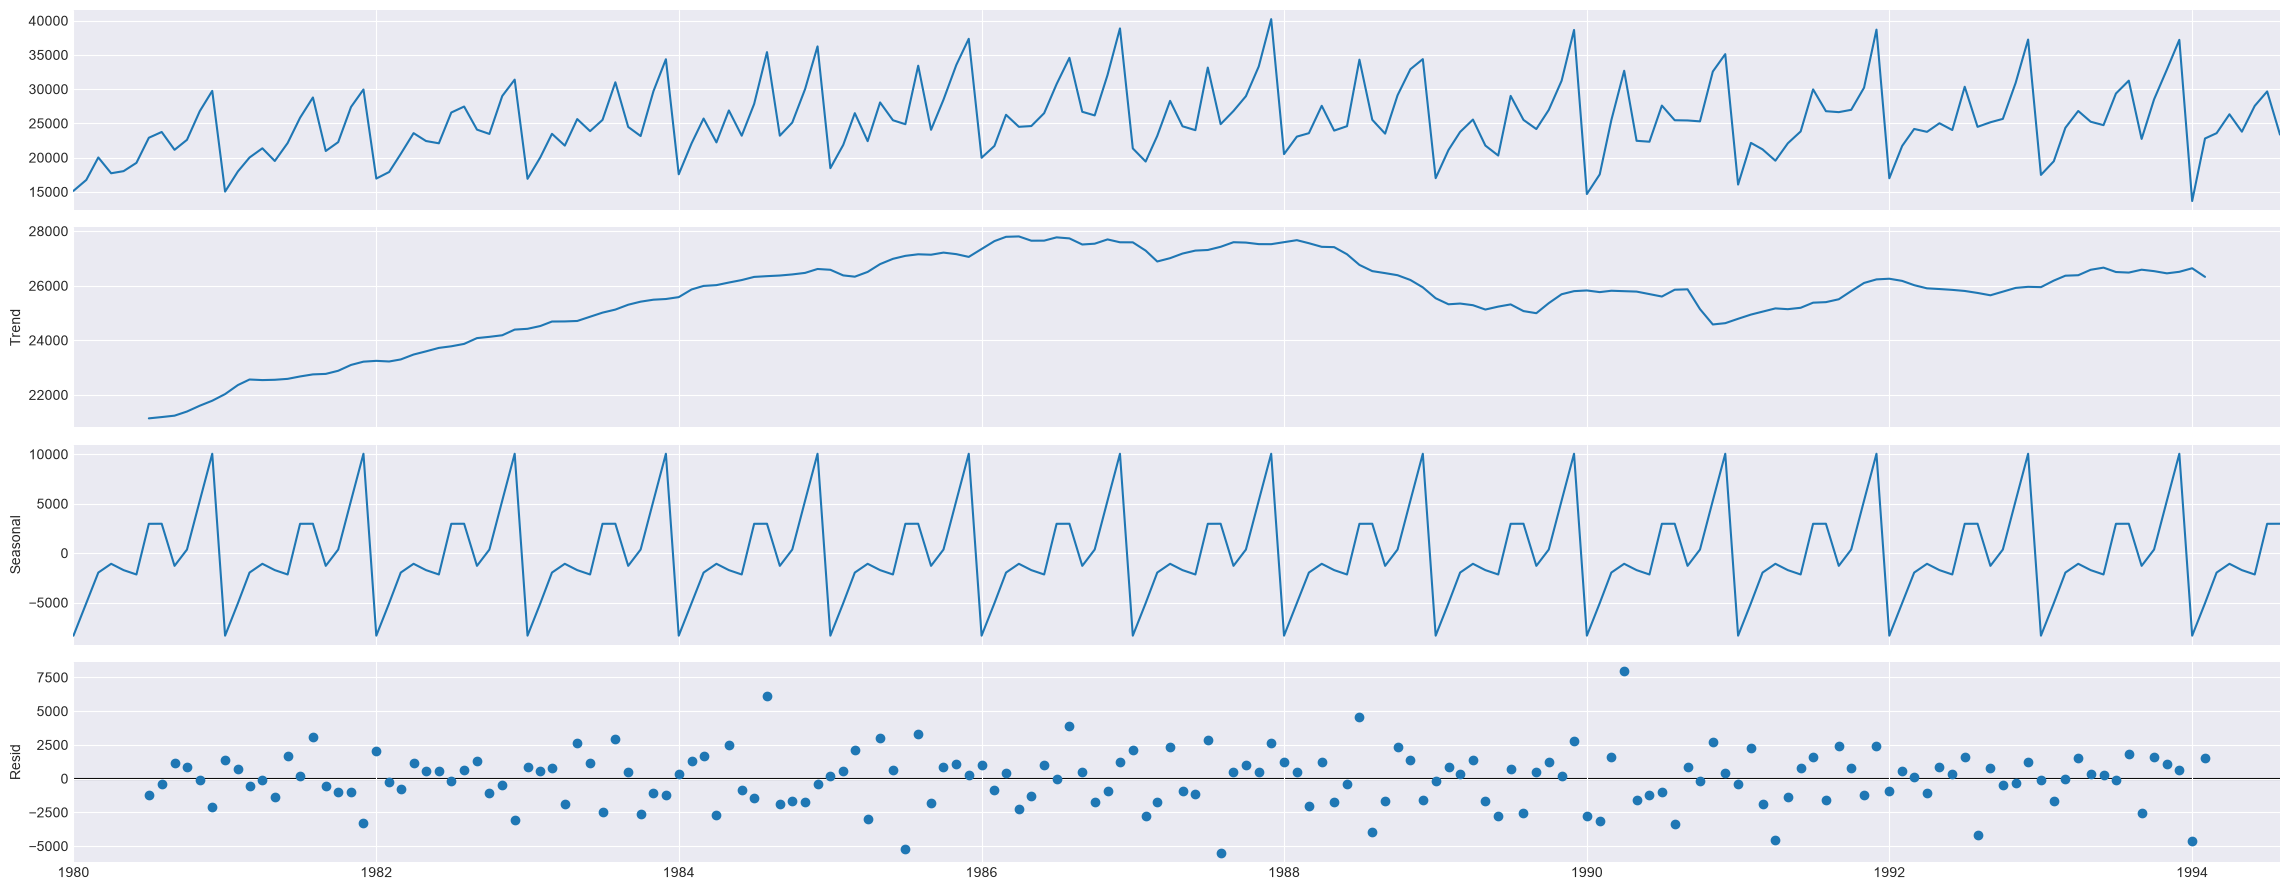

In [5]:
# period определяется автоматически из частоты индекса
decompose = seasonal_decompose(df, model="additive", period=None, two_sided=True)
_ = decompose.plot()

Период можно задать вручную; `two_sided=False` считает скользящее среднее только по прошлому (полезно, если важна причинность).

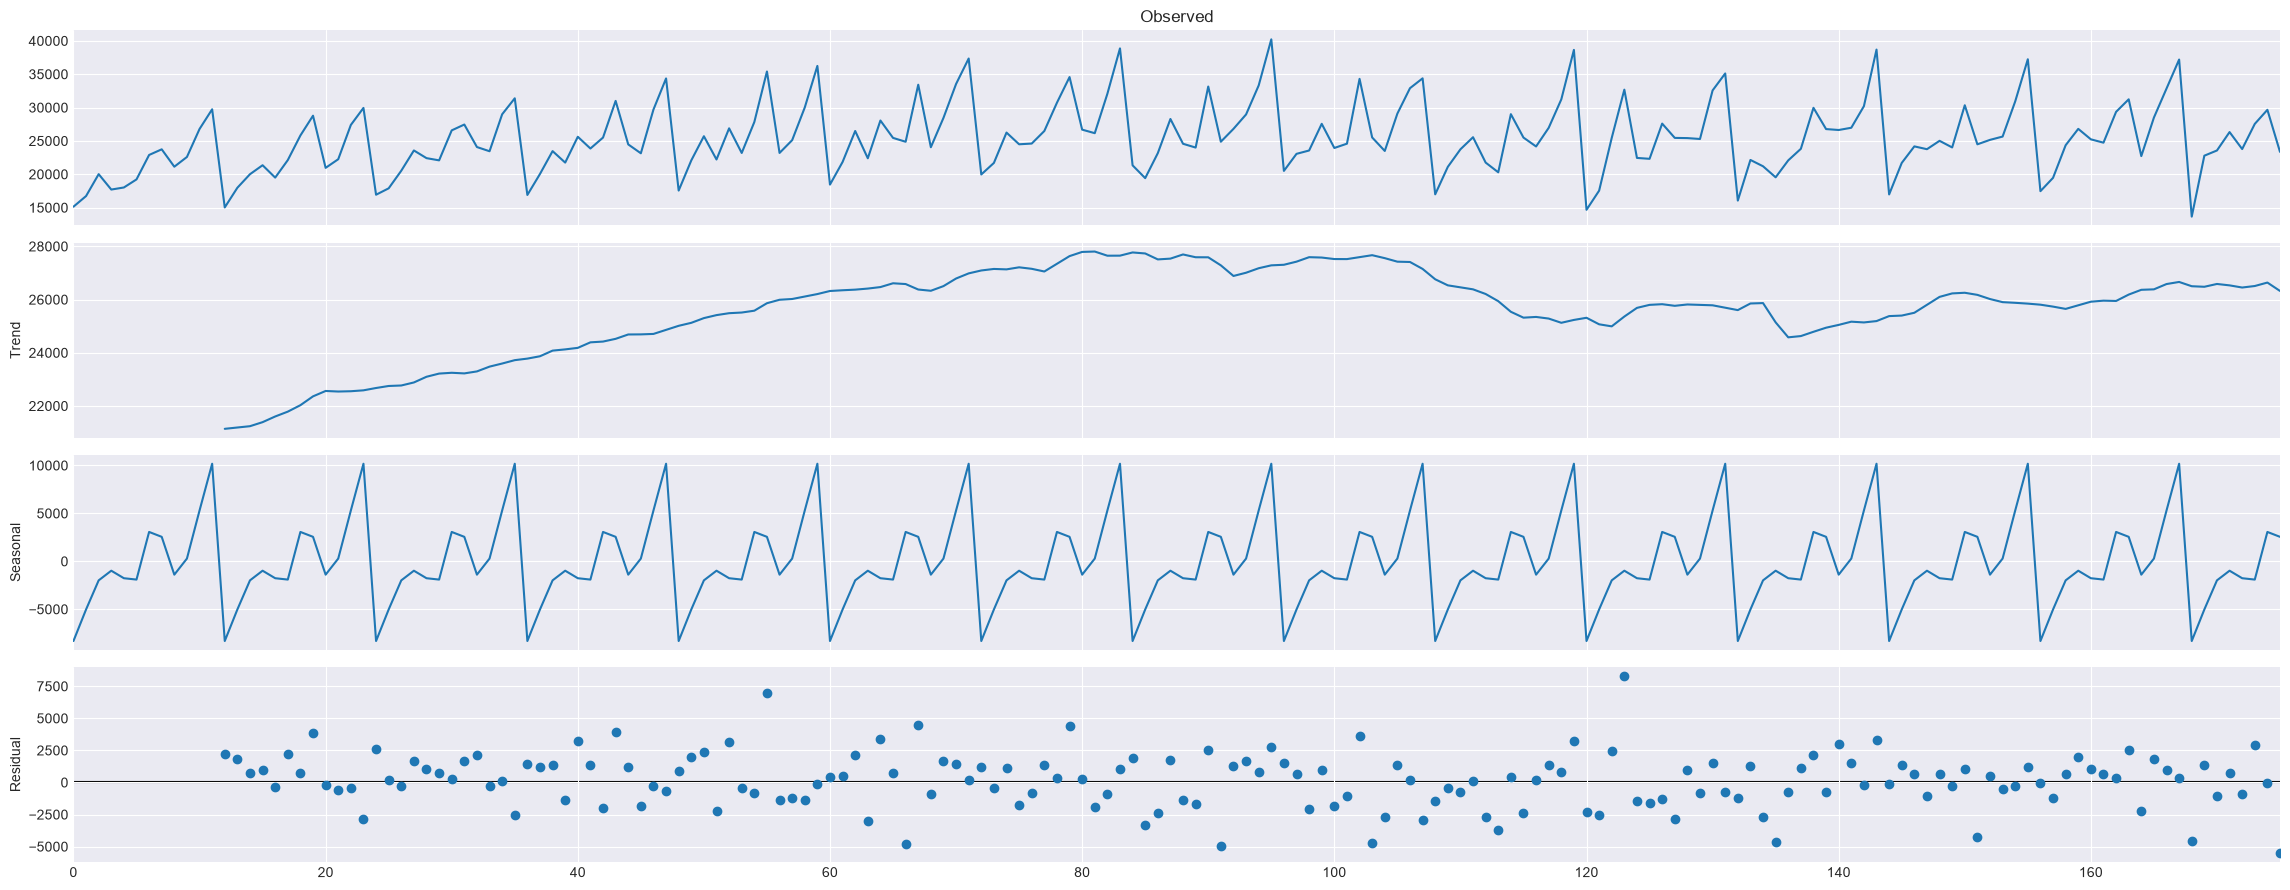

In [6]:
decompose = seasonal_decompose(df.values, model="additive", period=12, two_sided=False)
_ = decompose.plot()

Более гибкая альтернатива — **STL** (Seasonal-Trend decomposition using Loess): устойчива к выбросам и допускает медленно меняющуюся сезонность.

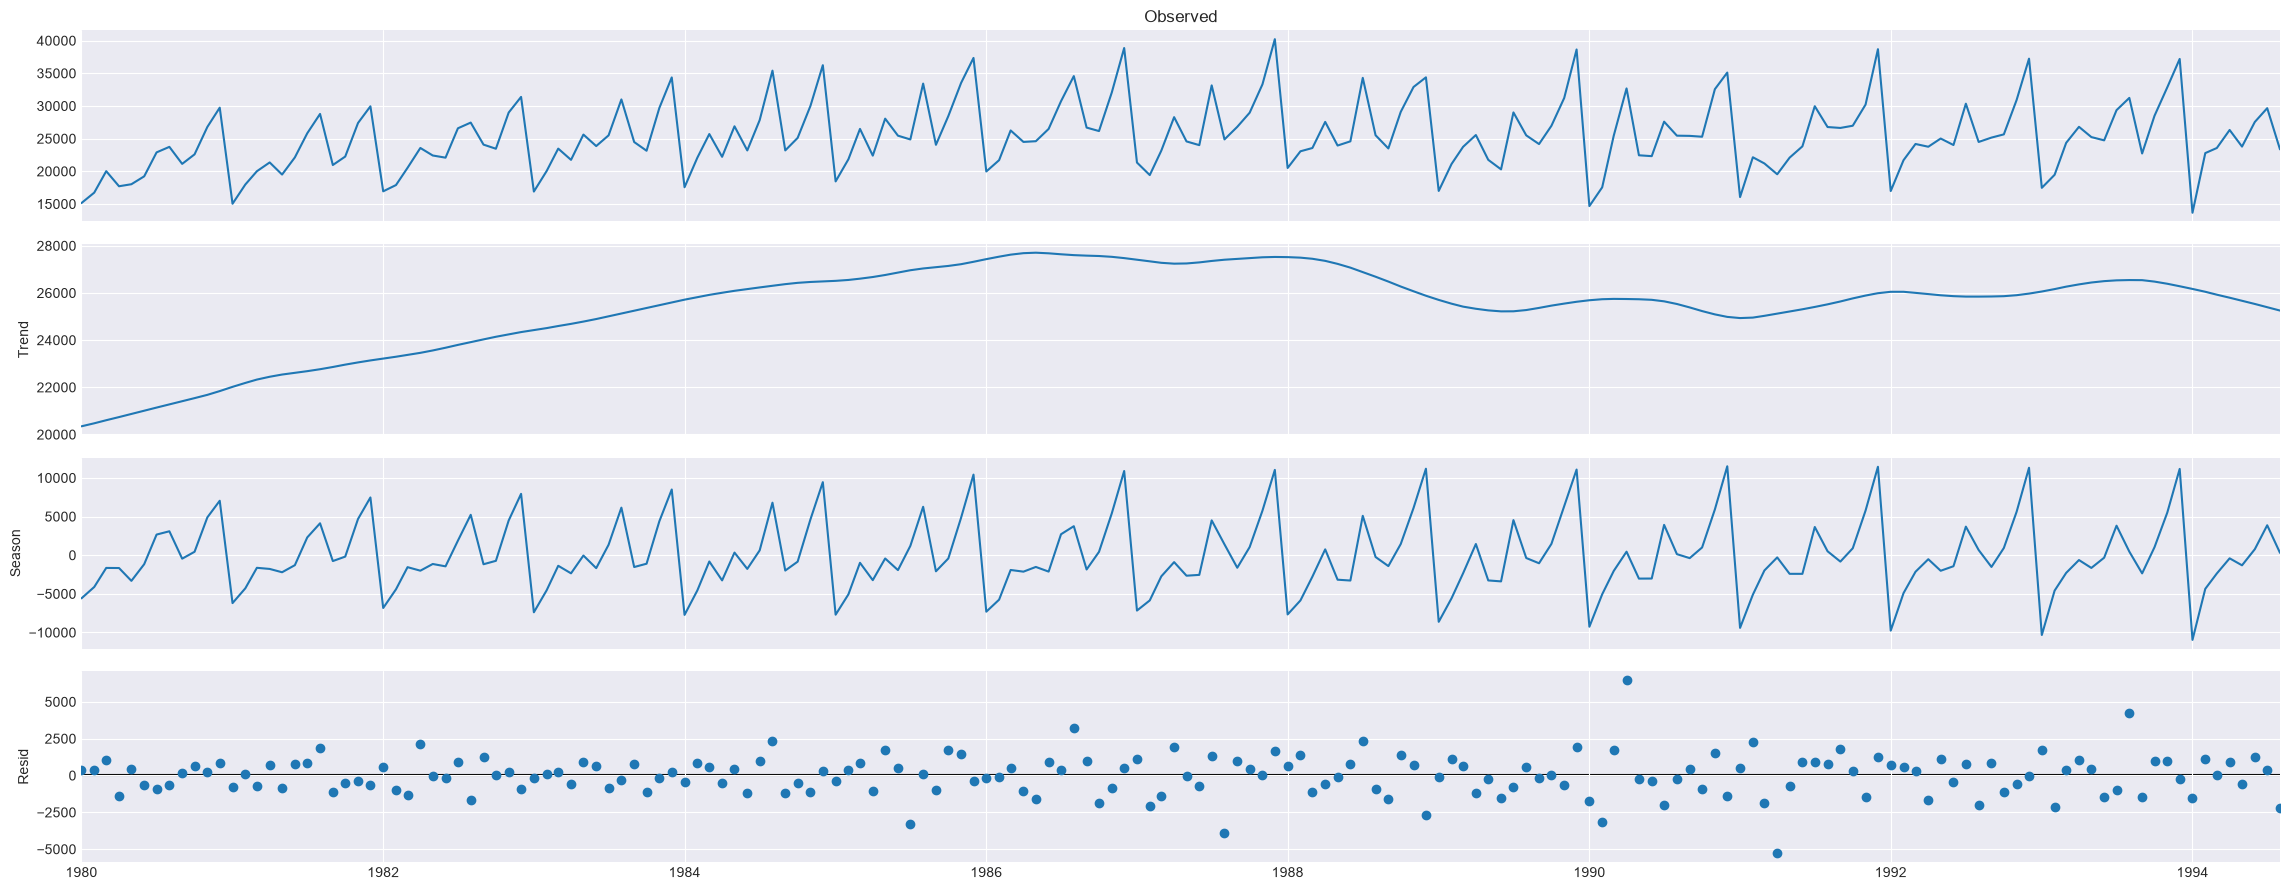

In [7]:
stl = STL(
    df,
    period=None,  # напр. 12
    seasonal=7,  # длина окна сглаживания сезонной компоненты (нечётное)
    trend=None,
    robust=None,
)
res = stl.fit()
_ = res.plot()

## 2. Сезонные графики

Разложение показывает «усреднённую» сезонность. Чтобы **сравнить сезонные профили между периодами**, удобны специальные графики.

**Seasonal plot**: по оси X — позиция внутри сезона (месяц), линии — разные годы. Так видно, повторяется ли форма из года в год и есть ли тренд год к году.

In [8]:
df["year"] = df.index.year
df["month"] = df.index.month

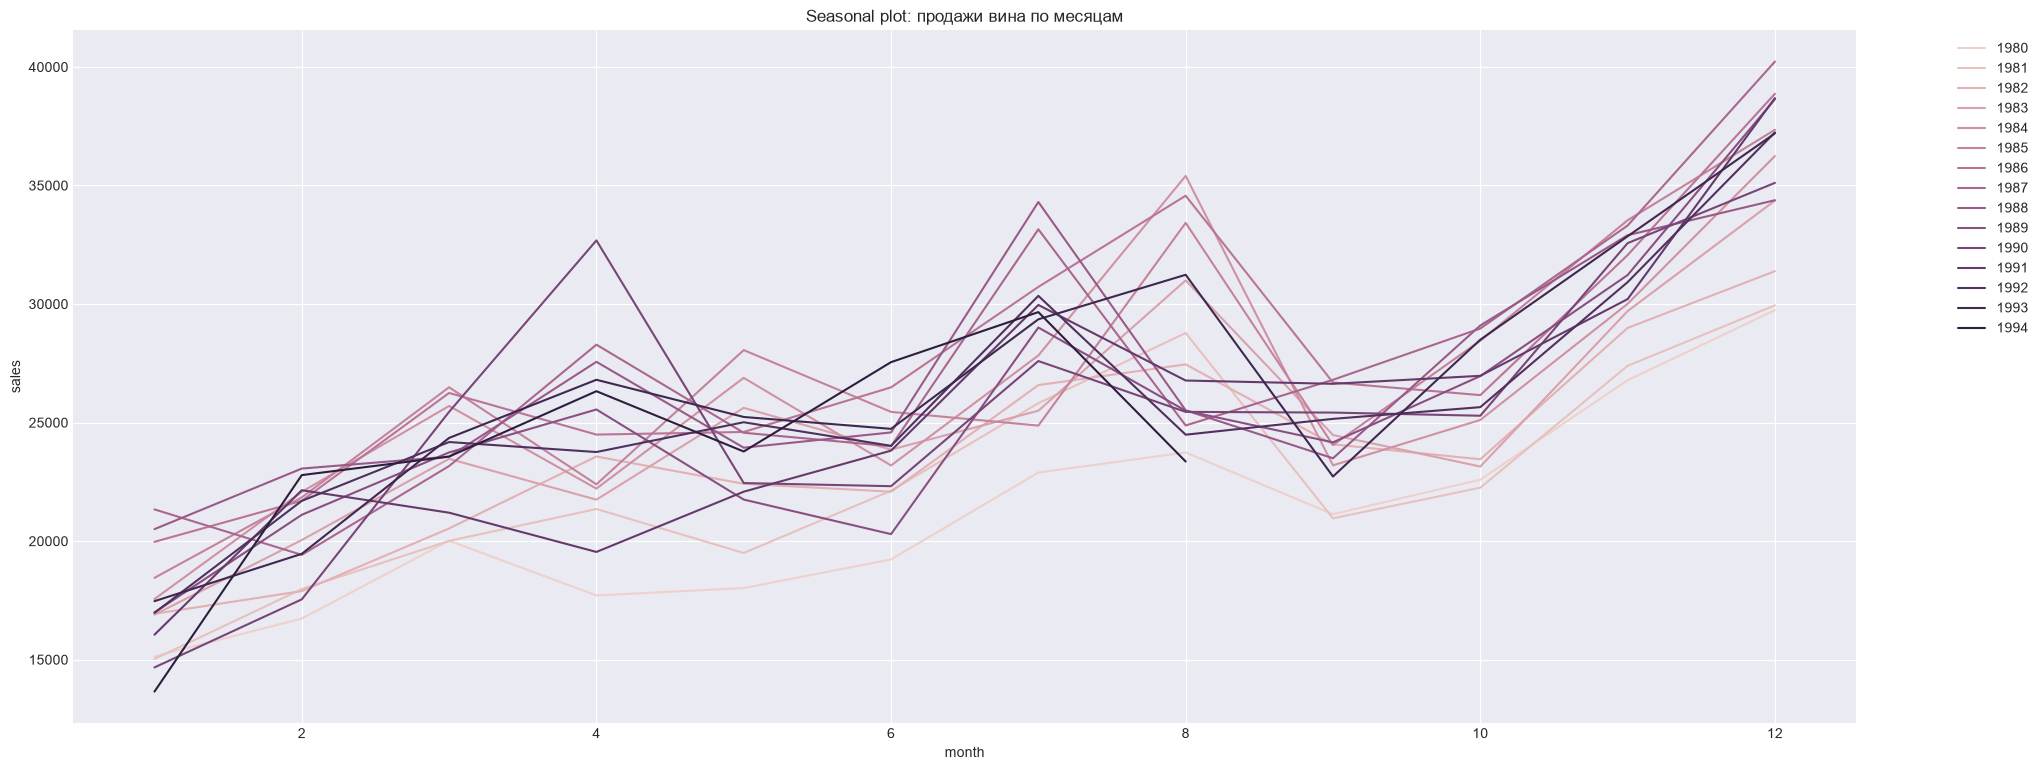

In [9]:
sns.lineplot(data=df, x="month", y="sales", hue="year", legend="full")
plt.title("Seasonal plot: продажи вина по месяцам")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2);

Те же графики полезны для panel-данных — можно смотреть сезонность по разным «календарным» осям.

In [10]:
df_panel["year"] = df_panel.index.year
df_panel["month"] = df_panel.index.month
df_panel["day_of_week"] = df_panel.index.weekday
df_panel["day_of_year"] = df_panel.index.dayofyear

Годовая сезонность: летом продажи ниже, чем зимой.

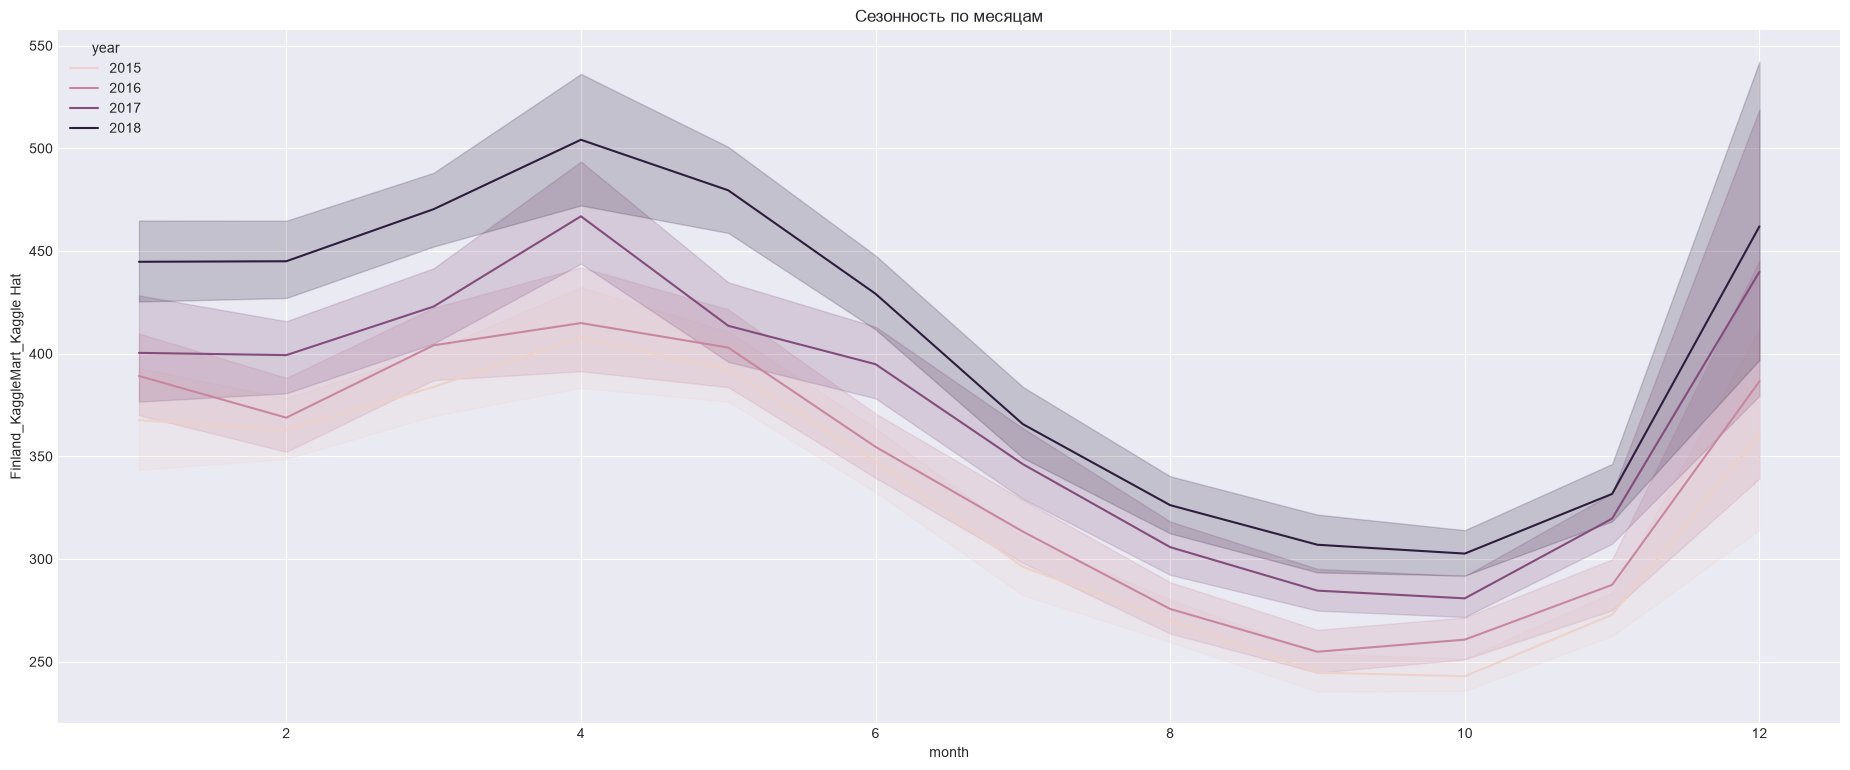

In [11]:
sns.lineplot(data=df_panel, x="month", y=segments[0], hue="year", legend="full")
plt.title("Сезонность по месяцам");

Недельная сезонность: в выходные продажи выше; заодно виден растущий тренд год к году.

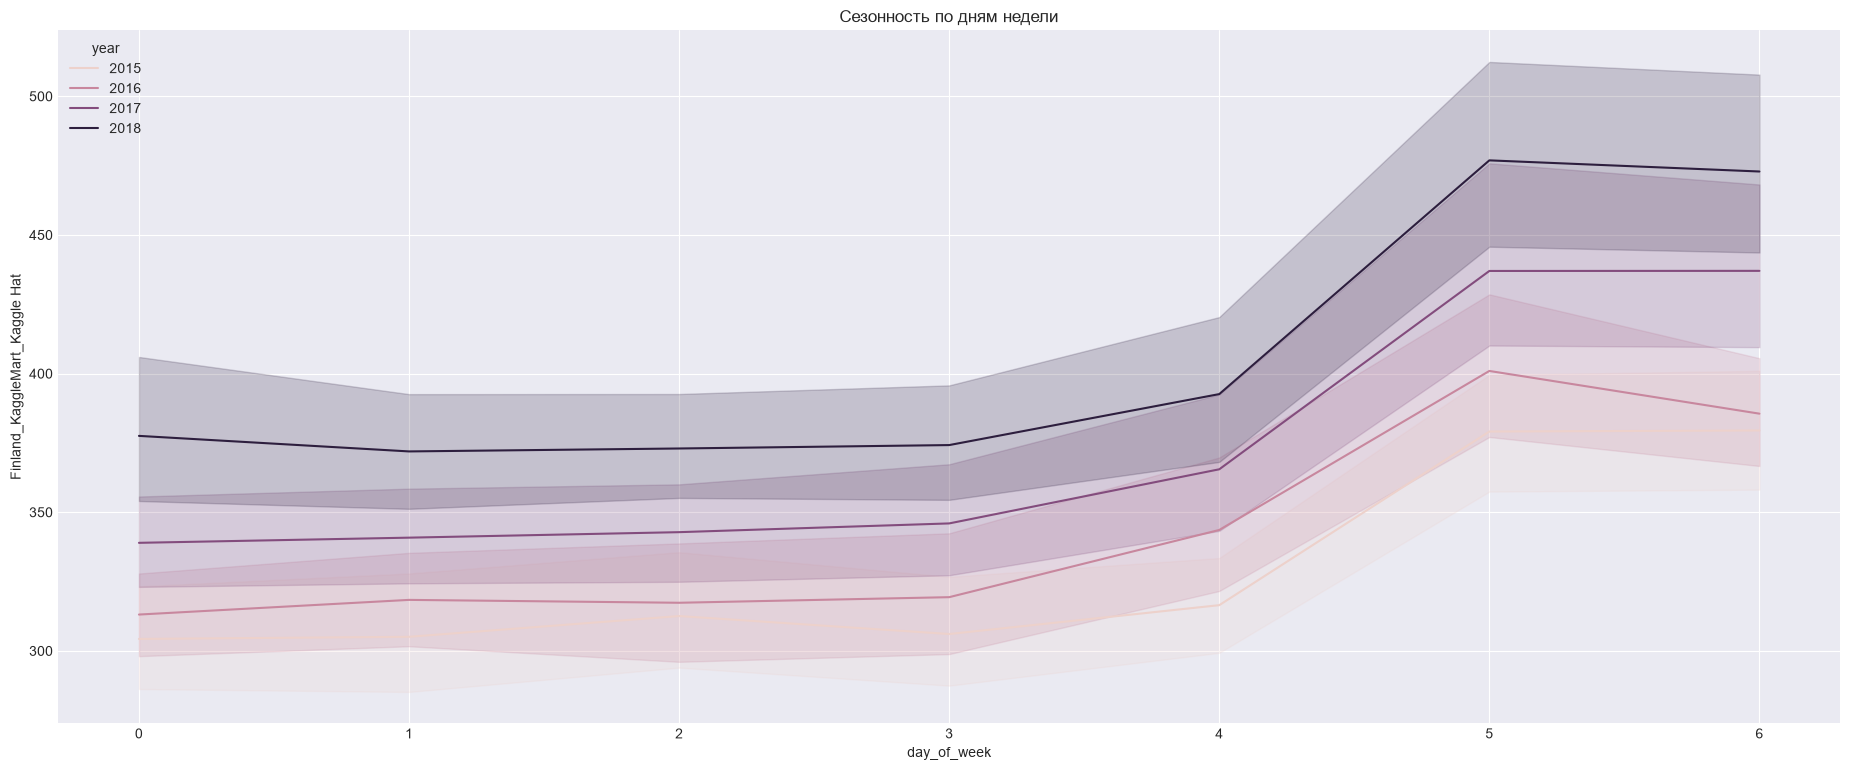

In [12]:
sns.lineplot(data=df_panel, x="day_of_week", y=segments[0], hue="year")
plt.title("Сезонность по дням недели");

У разных товаров профиль годовой сезонности отличается.

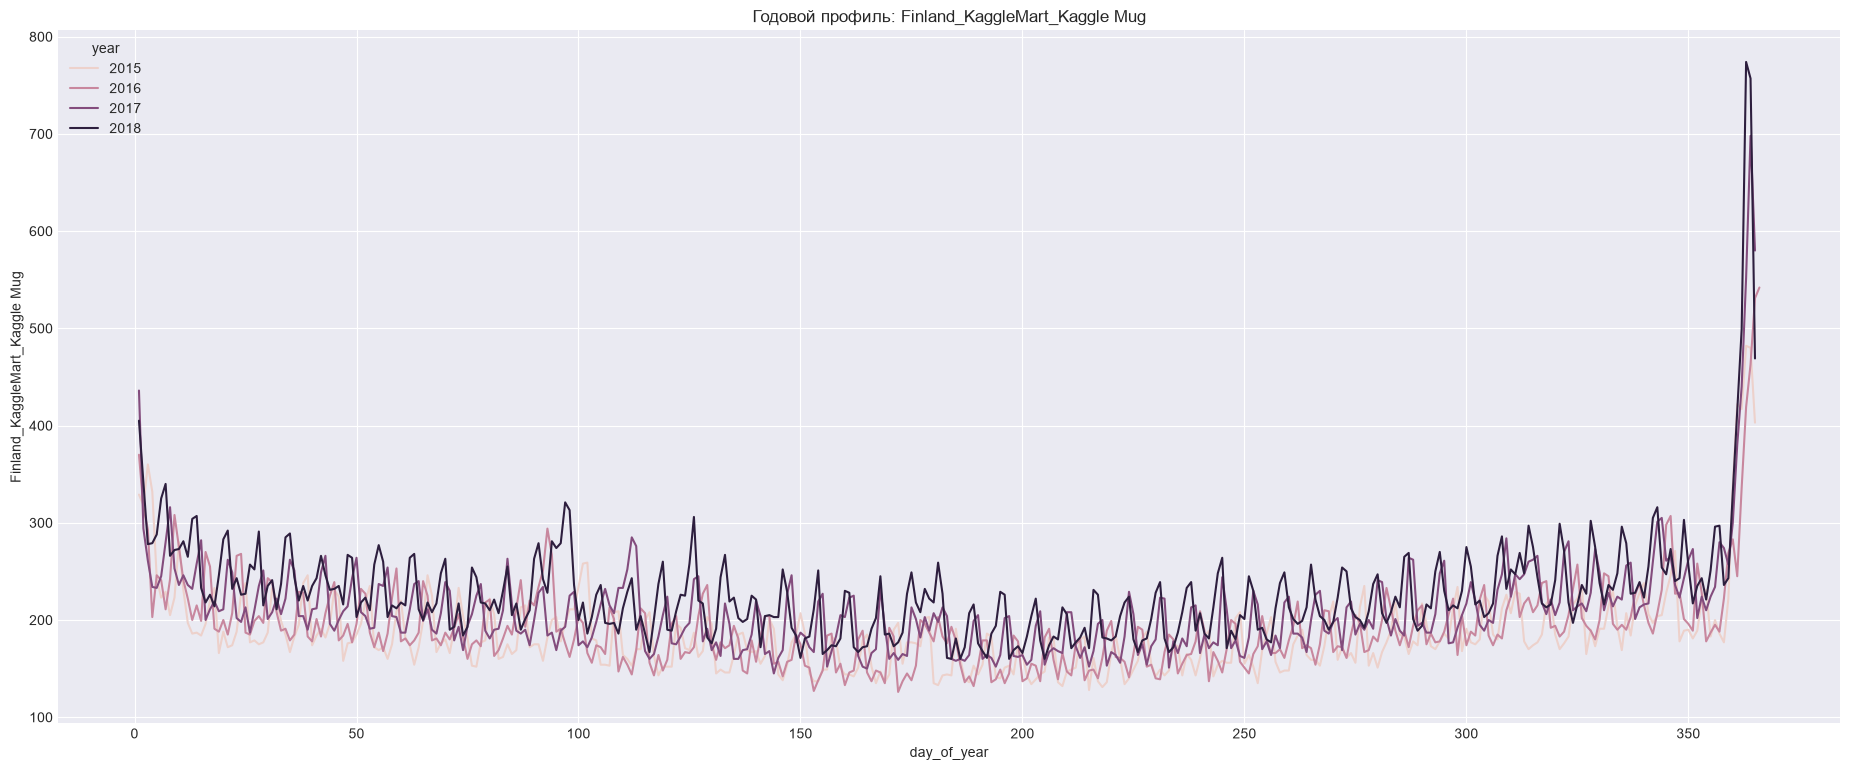

In [13]:
sns.lineplot(data=df_panel, x="day_of_year", y=segments[1], hue="year")
plt.title(f"Годовой профиль: {segments[1]}");

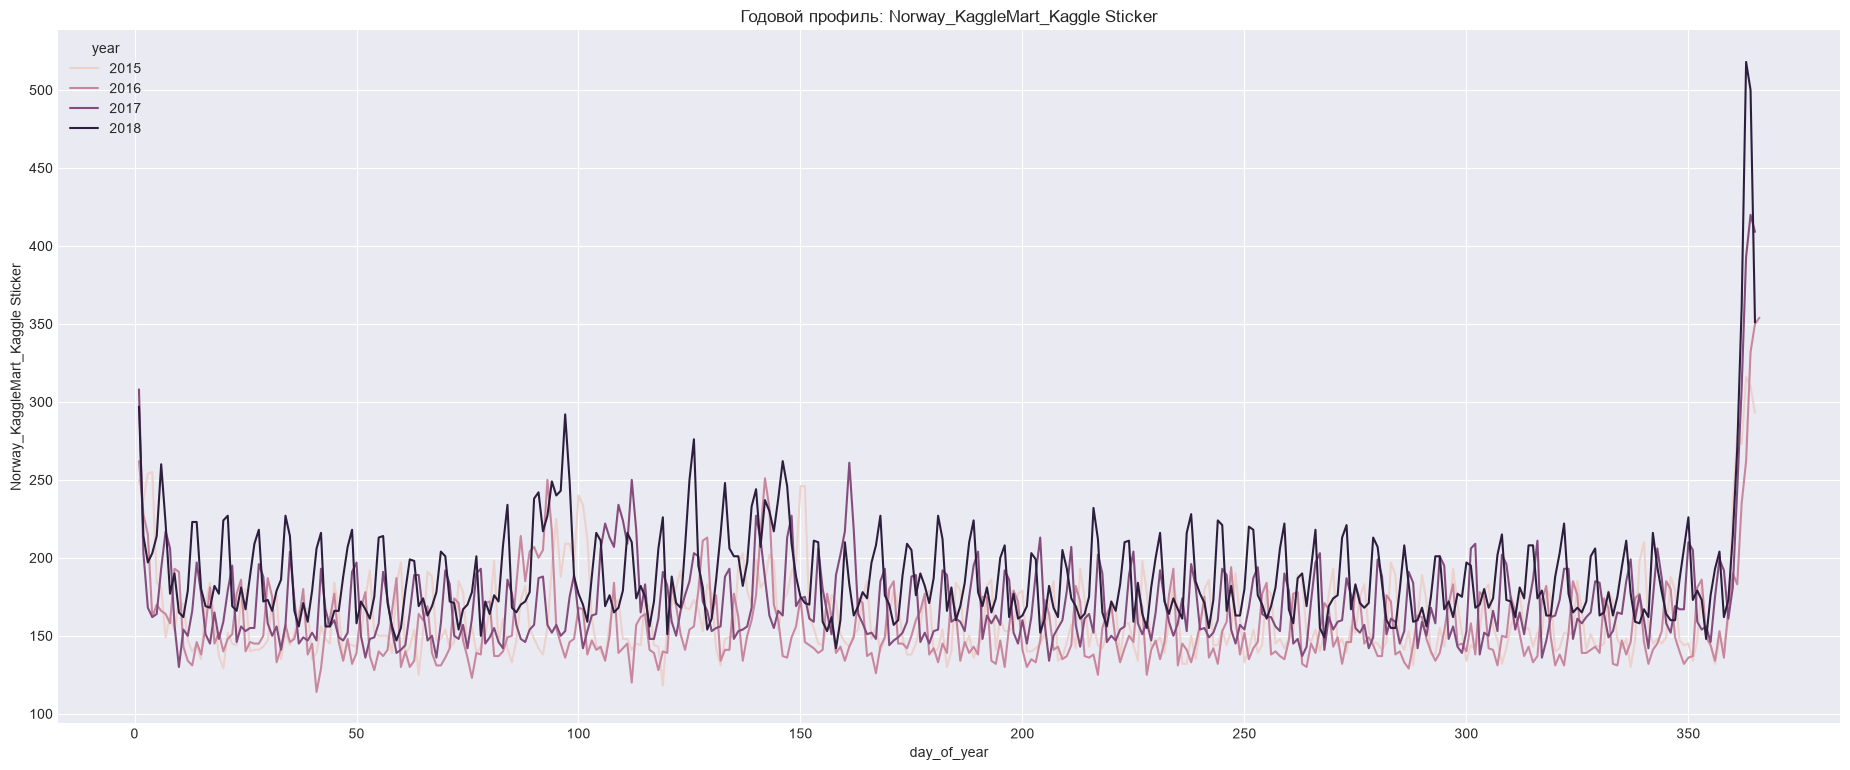

In [14]:
sns.lineplot(data=df_panel, x="day_of_year", y=segments[8], hue="year")
plt.title(f"Годовой профиль: {segments[8]}");

### Специальные сезонные графики statsmodels

На классическом датасете `flights` (пассажиры авиалиний) покажем ещё три полезных представления: `month_plot`, `quarter_plot` и полярный сезонный график.

In [15]:
from datetime import datetime

import plotly.express as px
from statsmodels.graphics.tsaplots import month_plot, quarter_plot

flights = sns.load_dataset("flights")
flights["report_date"] = flights.apply(
    lambda x: datetime.strptime(f"{x['year']}-{x['month']}", "%Y-%b").date(), axis=1
)
flights.head()

,year,month,passengers,report_date
0,1949,Jan,112,1949-01-01
1,1949,Feb,118,1949-02-01
2,1949,Mar,132,1949-03-01
3,1949,Apr,129,1949-04-01
4,1949,May,121,1949-05-01


`month_plot` рисует для каждого месяца его значения по годам и среднее — видно и профиль, и тренд внутри каждого месяца.

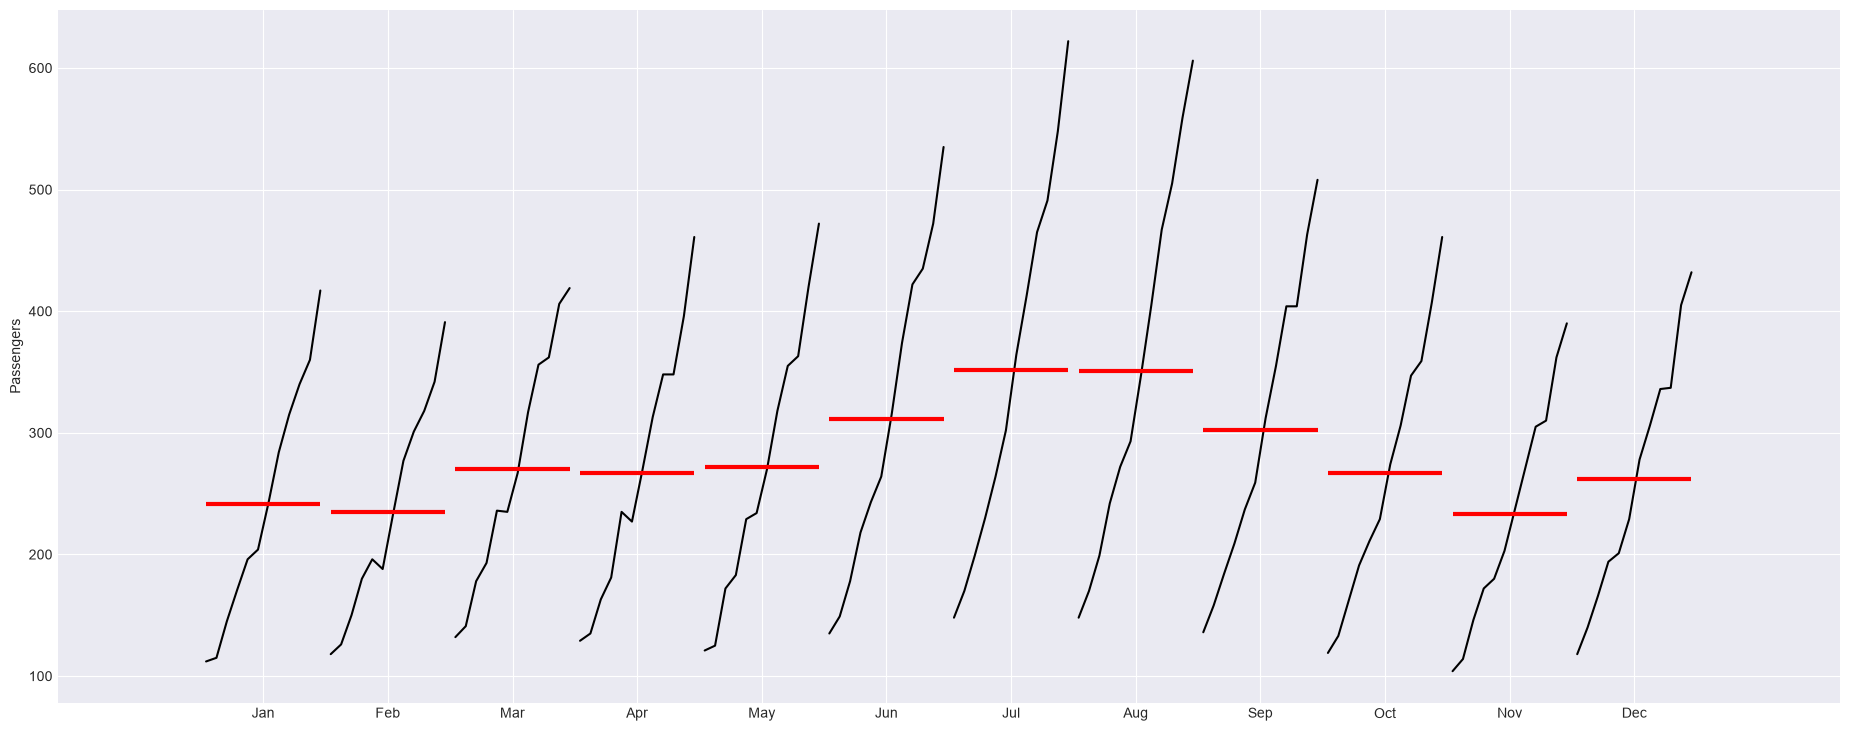

In [16]:
flights_ts = flights.set_index("report_date").copy()
flights_ts.index = pd.DatetimeIndex(flights_ts.index, freq="MS")
month_plot(flights_ts["passengers"], ylabel="Passengers");

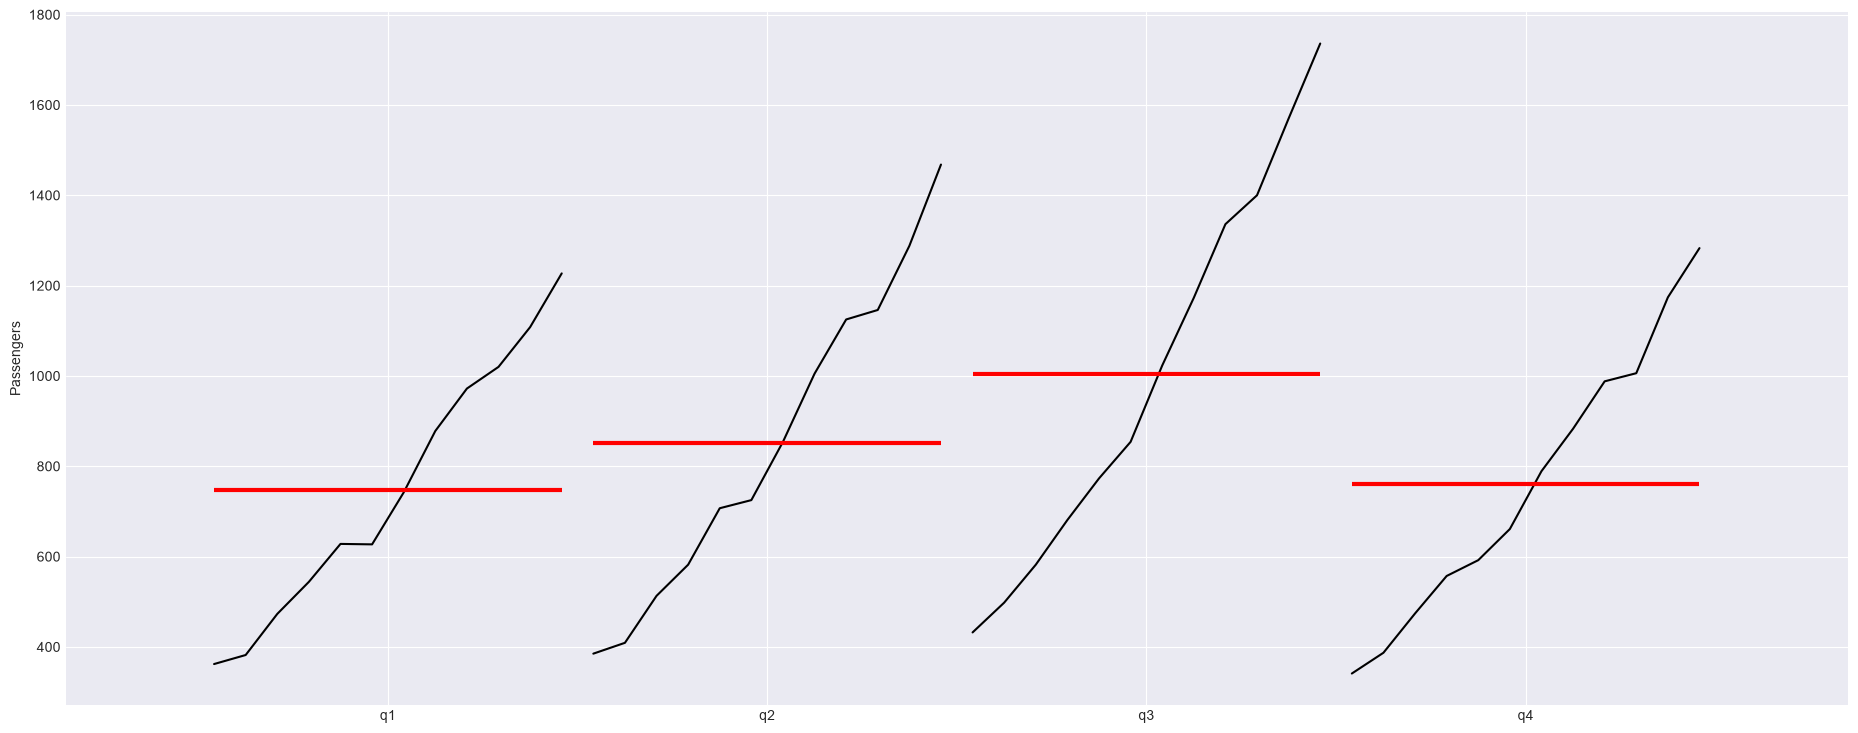

In [17]:
quarter_plot(flights_ts["passengers"].resample("Q").sum(), ylabel="Passengers");

**Polar seasonal plot** — тот же сезонный профиль в полярных координатах, наглядно показывает цикличность.

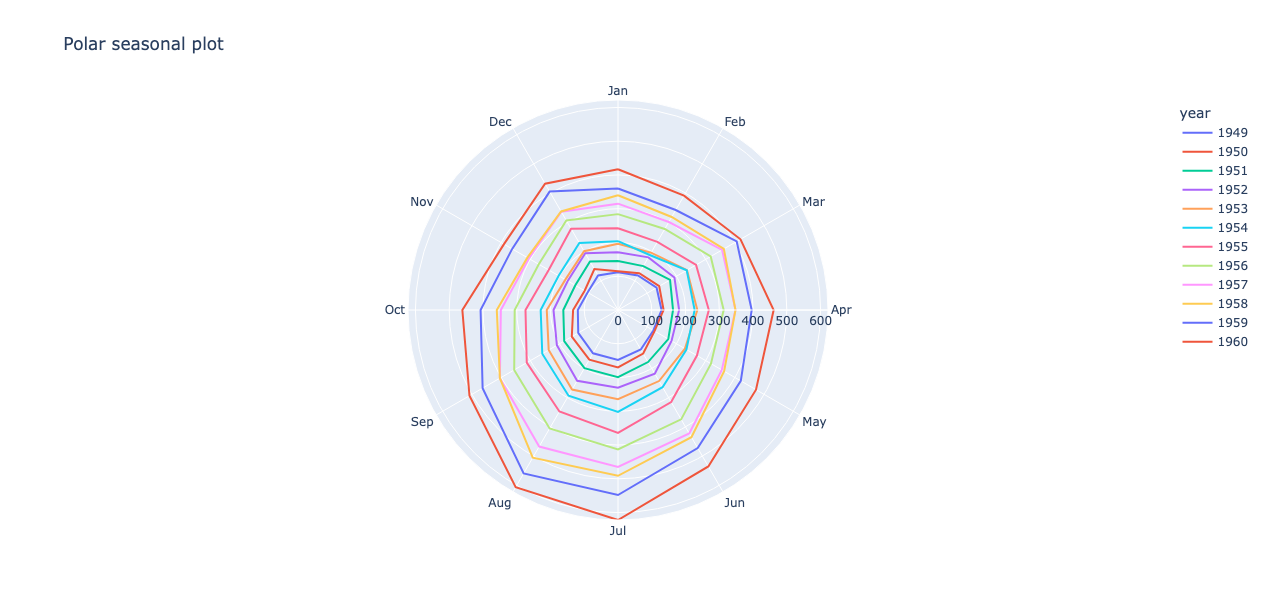

In [18]:
fig = px.line_polar(
    flights,
    r="passengers",
    theta="month",
    color="year",
    line_close=True,
    title="Polar seasonal plot",
    width=800,
    height=600,
)
fig.show()

## 3. Стационарность

Одно из важнейших свойств случайного процесса — **стационарность**.

Процесс $X_t$ **стационарен в узком смысле**, если все его конечномерные распределения инвариантны относительно сдвига по времени: для любых $t_1,\ldots,t_n$, любых $x_1,\ldots,x_n$ и любого $h>0$

$$\mathbb{P}\{X_{t_1}\le x_1,\ldots,X_{t_n}\le x_n\}=\mathbb{P}\{X_{t_1+h}\le x_1,\ldots,X_{t_n+h}\le x_n\}.$$

На практике это условие почти недостижимо, поэтому используют **слабую (стационарность в широком смысле)**: постоянны только первые два момента —

$$\mathbb{E}X_t = \text{const}, \qquad \mathrm{Cov}(X_{t+h}, X_{s+h}) = \mathrm{Cov}(X_t, X_s).$$

То есть у всех точек одинаковые матожидание и дисперсия, а ковариация зависит лишь от расстояния между точками. (Для гауссовских процессов слабая стационарность влечёт сильную.)

Сгенерируем модельный ряд: сначала стационарный белый шум, а затем «испортим» его — сдвигом среднего, трендом и ростом дисперсии.

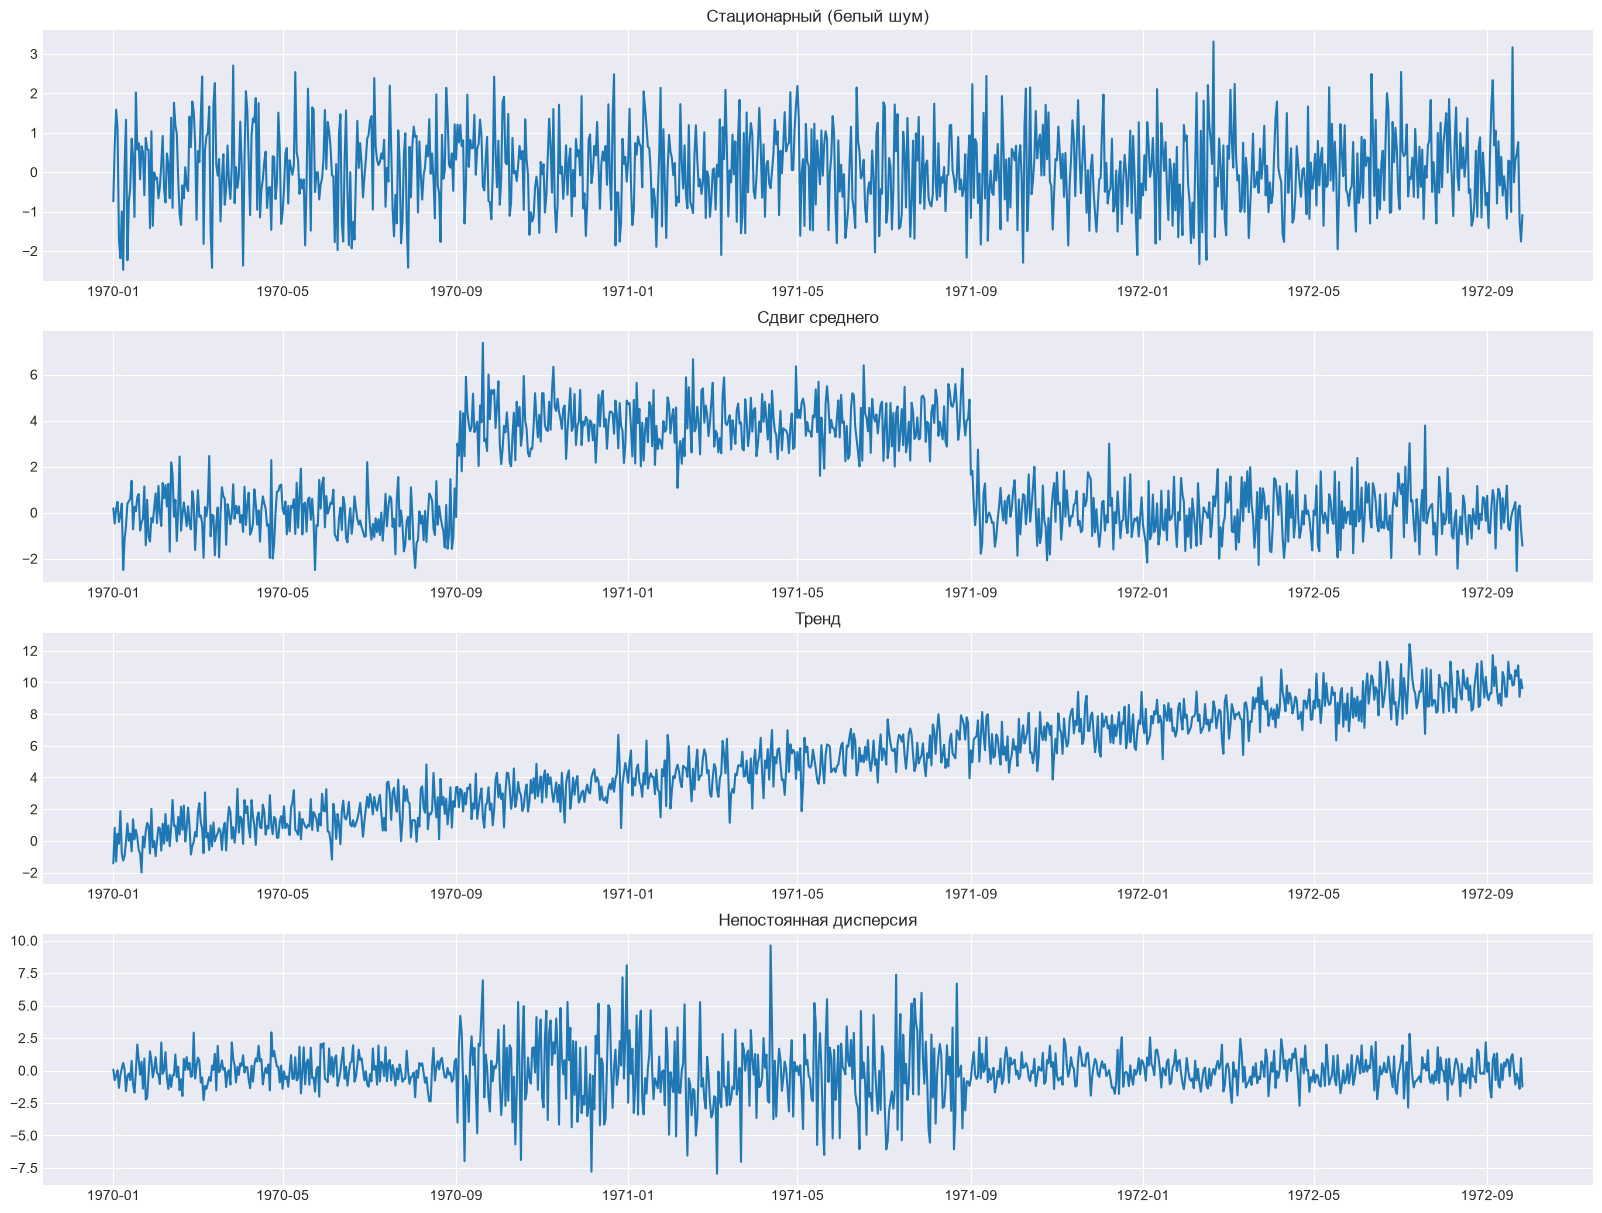

In [19]:
n_sim = 1000
index = pd.date_range(start="01.01.1970", periods=n_sim, freq="D")
fig, ax = plt.subplots(nrows=4, figsize=(20, 15))

# 1) стационарный белый шум
ax[0].plot(pd.Series(np.random.normal(size=n_sim), index=index))
ax[0].set_title("Стационарный (белый шум)")

# 2) скачок среднего -> нарушено постоянство матожидания
ax[1].plot(
    pd.Series(
        np.random.normal(size=n_sim) + (index > "1970-09") * 4 - (index > "1971-09") * 4,
        index=index,
    )
)
ax[1].set_title("Сдвиг среднего")

# 3) линейный тренд
ax[2].plot(pd.Series(np.random.normal(size=n_sim) + np.arange(n_sim) / 100, index=index))
ax[2].set_title("Тренд")

# 4) меняющаяся дисперсия
ax[3].plot(
    pd.Series(
        np.random.normal(scale=1 + (index > "1970-09") * 2 - (index > "1971-09") * 2, size=n_sim),
        index=index,
    )
)
ax[3].set_title("Непостоянная дисперсия");

### Статистические тесты на стационарность

Проверяют стационарность формально. Обратите внимание на **противоположные нулевые гипотезы**:
- **ADF (Дики-Фуллера)**: $H_0$ — ряд **не**стационарен (есть единичный корень);
- **KPSS**: $H_0$ — ряд **стационарен**.

Их удобно использовать вместе: согласованный вердикт надёжнее.

In [20]:
from statsmodels.tsa.stattools import adfuller, kpss


def adf_test(timeseries):  # H0: ряд НЕстационарен
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    print(pd.Series(dftest[0:2], index=["Test Statistic", "p-value"]))


def kpss_test(timeseries):  # H0: ряд стационарен
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    print(pd.Series(kpsstest[0:2], index=["Test Statistic", "p-value"]))

Продажи вина — нестационарны (есть тренд и сезонность): ADF не отвергает $H_0$, KPSS отвергает.

In [21]:
adf_test(df["sales"])

Results of Dickey-Fuller Test:
Test Statistic   -2.852468
p-value           0.051161
dtype: float64


In [22]:
kpss_test(df["sales"])

Results of KPSS Test:
Test Statistic    0.966011
p-value           0.010000
dtype: float64


/var/folders/p_/lhmc40f91qn_m64frv3rrz6h0000gq/T/ipykernel_36568/1284138871.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


Panel-ряд — тоже нестационарен.

In [23]:
adf_test(df_panel[segments[0]])

Results of Dickey-Fuller Test:
Test Statistic   -2.486671
p-value           0.118751
dtype: float64


In [24]:
kpss_test(df_panel[segments[0]])

Results of KPSS Test:
Test Statistic    0.653229
p-value           0.017797
dtype: float64


А вот **белый шум** стационарен — теория работает.

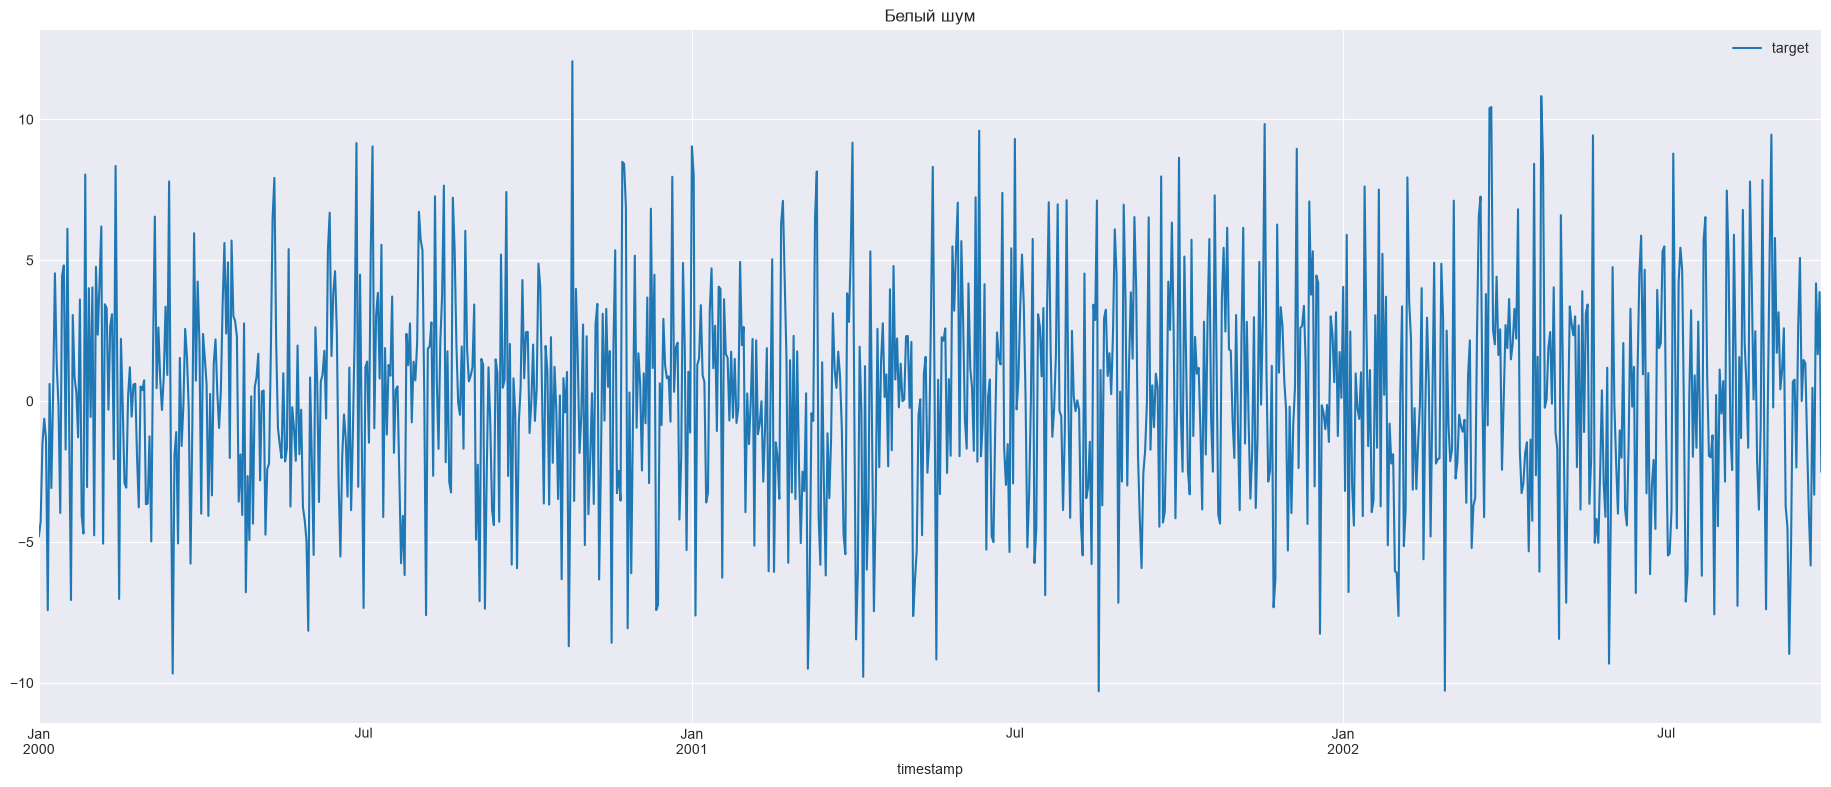

In [25]:
num_samples = 1000
df_white_noise = pd.DataFrame(
    {
        "target": np.random.normal(0, 4, size=num_samples),
        "timestamp": pd.date_range(start="2000-01-01", freq="D", periods=num_samples),
    }
)
df_white_noise.set_index("timestamp").plot()
plt.title("Белый шум");

In [26]:
adf_test(df_white_noise["target"])

Results of Dickey-Fuller Test:
Test Statistic   -29.882915
p-value            0.000000
dtype: float64


In [27]:
kpss_test(df_white_noise["target"])

Results of KPSS Test:
Test Statistic    0.042891
p-value           0.100000
dtype: float64


/var/folders/p_/lhmc40f91qn_m64frv3rrz6h0000gq/T/ipykernel_36568/1284138871.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


## 4. Автокорреляция

**Автокорреляция** измеряет, насколько текущее значение ряда связано с его прошлыми значениями. Например, сегодняшняя температура сильно коррелирует со вчерашней.

Чтобы говорить об этом, вводят понятие **лага** (задержки): сравниваем ряд с самим собой, сдвинутым на $k$ шагов. Автокорреляцией $k$-го порядка называют $\mathrm{corr}(y_t, y_{t-k})$. Обычно считают её для $k=1,\ldots,K$ и строят график (**ACF**).

### Лаги через `shift`

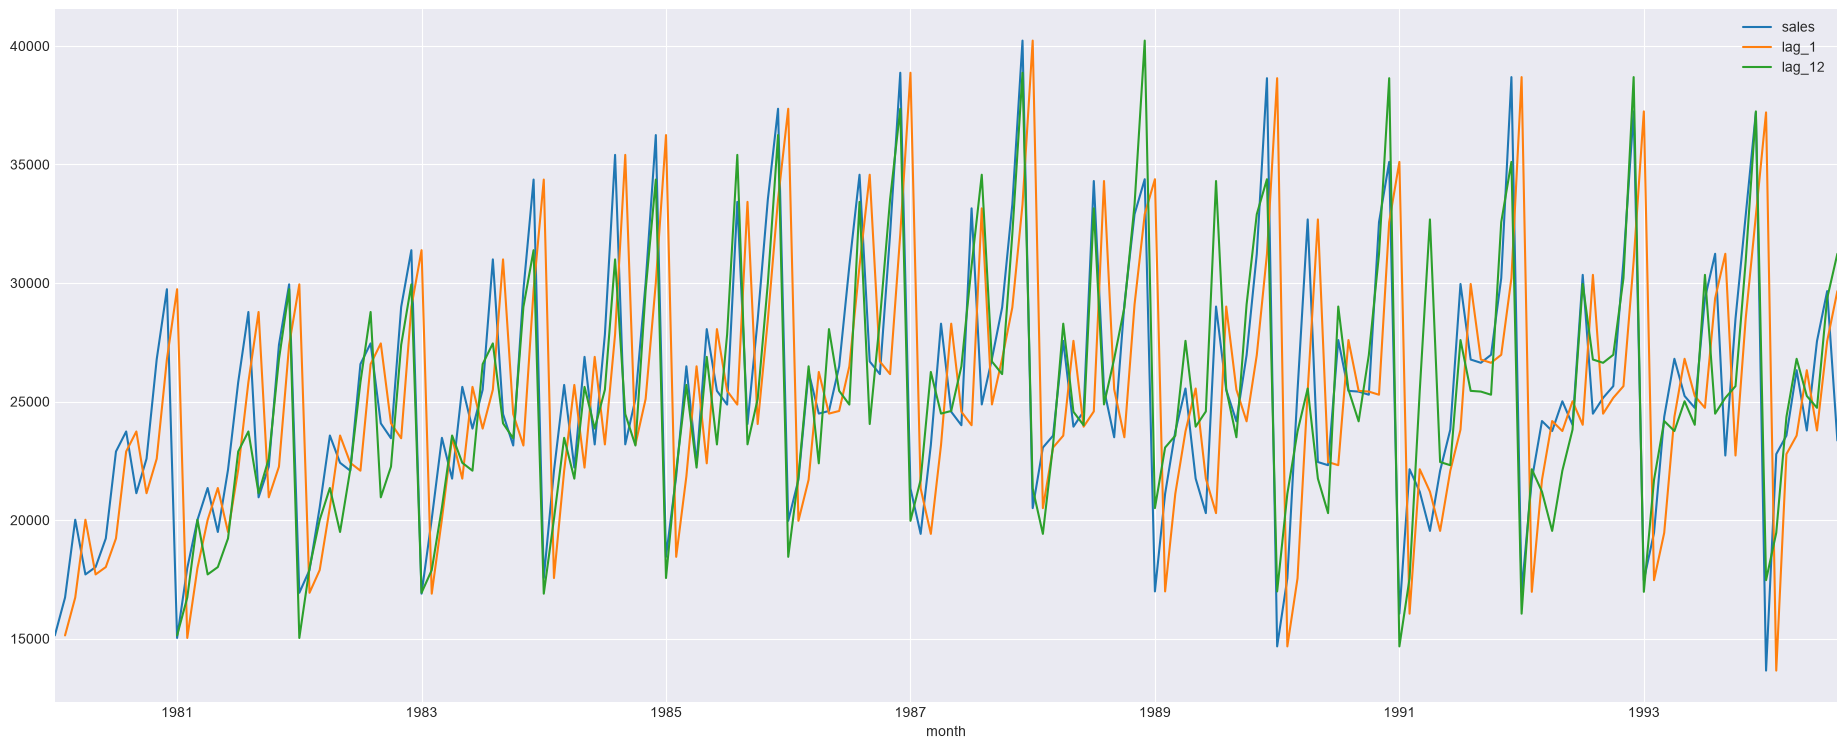

In [28]:
df["lag_1"] = df["sales"].shift(1)
df["lag_12"] = df["sales"].shift(12)
df[["sales", "lag_1", "lag_12"]].plot();

Для первых значений ряда соответствующие лаги неизвестны (`NaN`).

In [29]:
df.head(15)

,sales,year,month,lag_1,lag_12
month,,,,,
1980-01-01,15136,1980,1,NaN,NaN
1980-02-01,16733,1980,2,15136.0,NaN
1980-03-01,20016,1980,3,16733.0,NaN
1980-04-01,17708,1980,4,20016.0,NaN
1980-05-01,18019,1980,5,17708.0,NaN
1980-06-01,19227,1980,6,18019.0,NaN
1980-07-01,22893,1980,7,19227.0,NaN
1980-08-01,23739,1980,8,22893.0,NaN
1980-09-01,21133,1980,9,23739.0,NaN


### ACF — функция автокорреляции

Посчитаем первые 12 значений.

In [30]:
from statsmodels.graphics.tsaplots import acf

acf(df["sales"], nlags=12)

array([ 1.        ,  0.18534655, -0.14100836,  0.04107465,  0.23351811,
        0.03201183, -0.28606108,  0.04299276,  0.20297971,  0.01284998,
       -0.14668572,  0.15136433,  0.79996118])

Убедимся, что это действительно корреляция ряда со сдвинутой копией: сравним с `pearsonr`.

In [31]:
from scipy.stats import pearsonr

pearsonr(df["sales"], df["sales"])  # лаг 0 -> ровно 1

PearsonRResult(statistic=np.float64(1.0), pvalue=np.float64(0.0))

In [32]:
pearsonr(df["sales"][1:], df["lag_1"][1:])

PearsonRResult(statistic=np.float64(0.18739645451637202), pvalue=np.float64(0.013017278715611863))

In [33]:
pearsonr(df["sales"][12:], df["lag_12"][12:])

PearsonRResult(statistic=np.float64(0.8723105537937306), pvalue=np.float64(3.282291056148273e-52))

И вспомним формулу через ковариации ($\hat r_k = \hat\gamma_k / \hat\gamma_0$):

In [34]:
n = len(df)
cov_12 = (
    1
    / n
    * np.sum((df["sales"][12:] - df["sales"].mean()) * (df["lag_12"][12:] - df["sales"].mean()))
)
cov_0 = 1 / n * np.sum((df["sales"] - df["sales"].mean()) ** 2)
cov_12 / cov_0

np.float64(0.7999611775065133)

### График ACF

По коррелограмме удобно читать структуру ряда: значимые лаги выходят за доверительную полосу.

In [35]:
from statsmodels.graphics.tsaplots import plot_acf

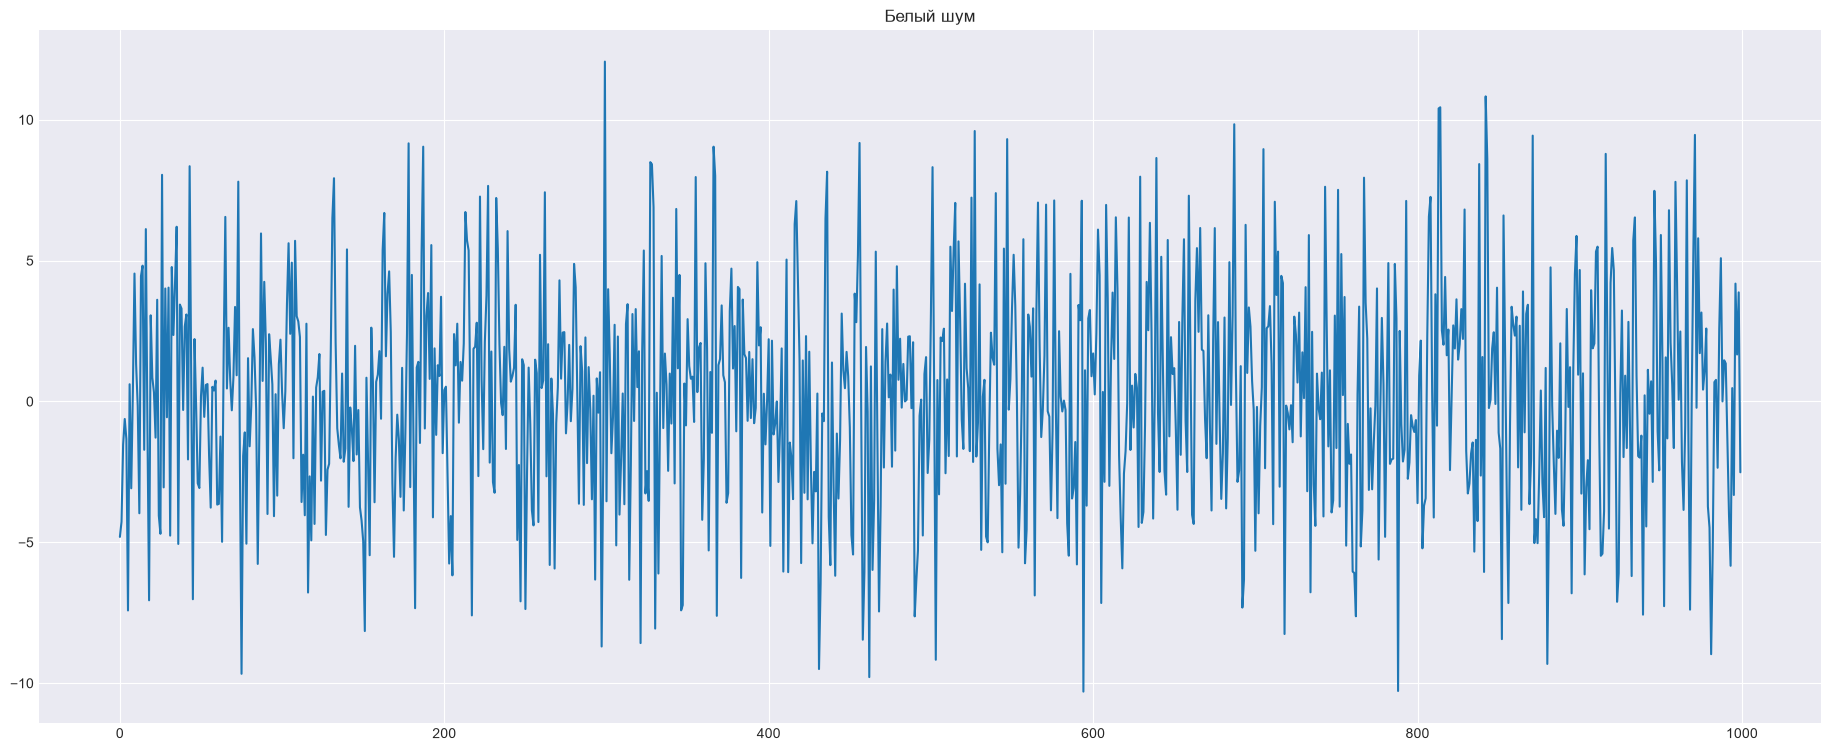

In [36]:
df_white_noise["target"].plot()
plt.title("Белый шум");

У белого шума значимых лагов нет — как и ожидалось.

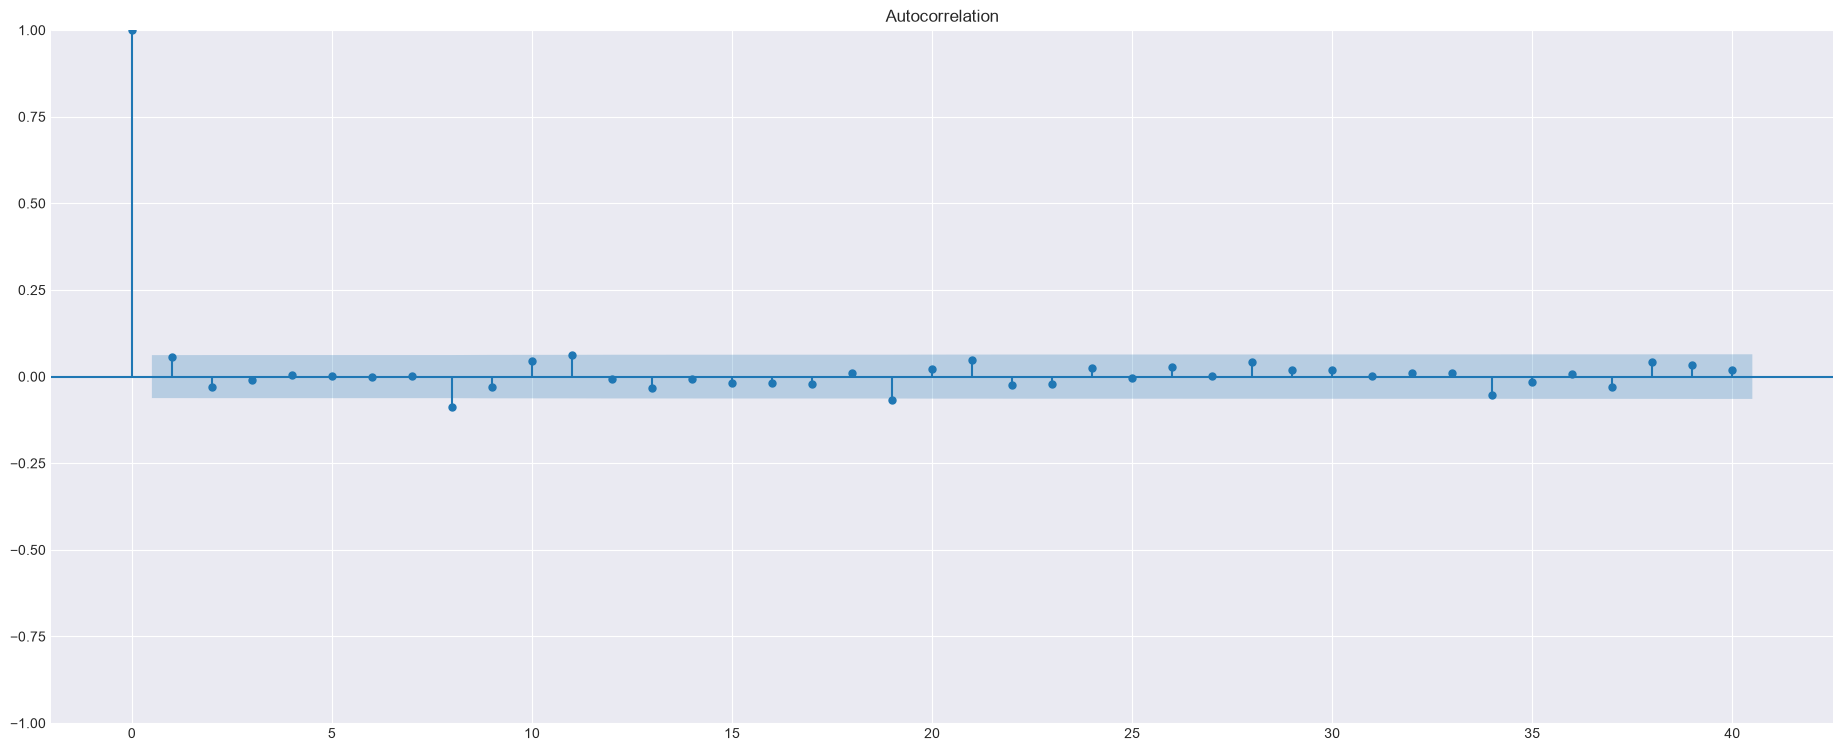

In [37]:
_ = plot_acf(df_white_noise["target"], lags=40)

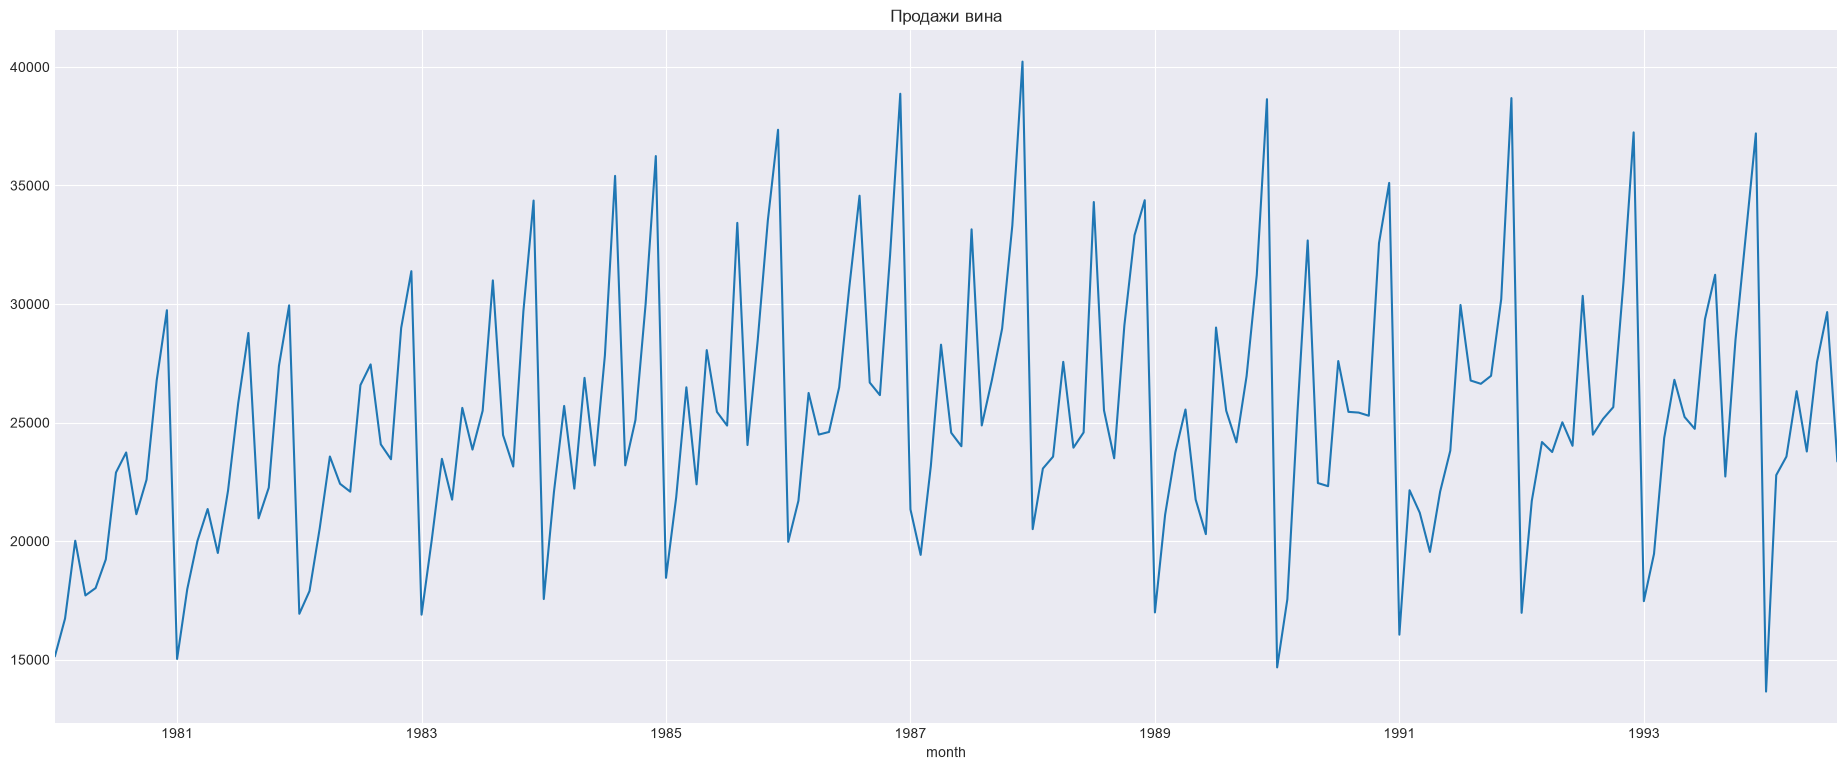

In [38]:
df["sales"].plot()
plt.title("Продажи вина");

У продаж вина видны значимые **сезонные** лаги 12, 24, 36, ... — годовая сезонность.

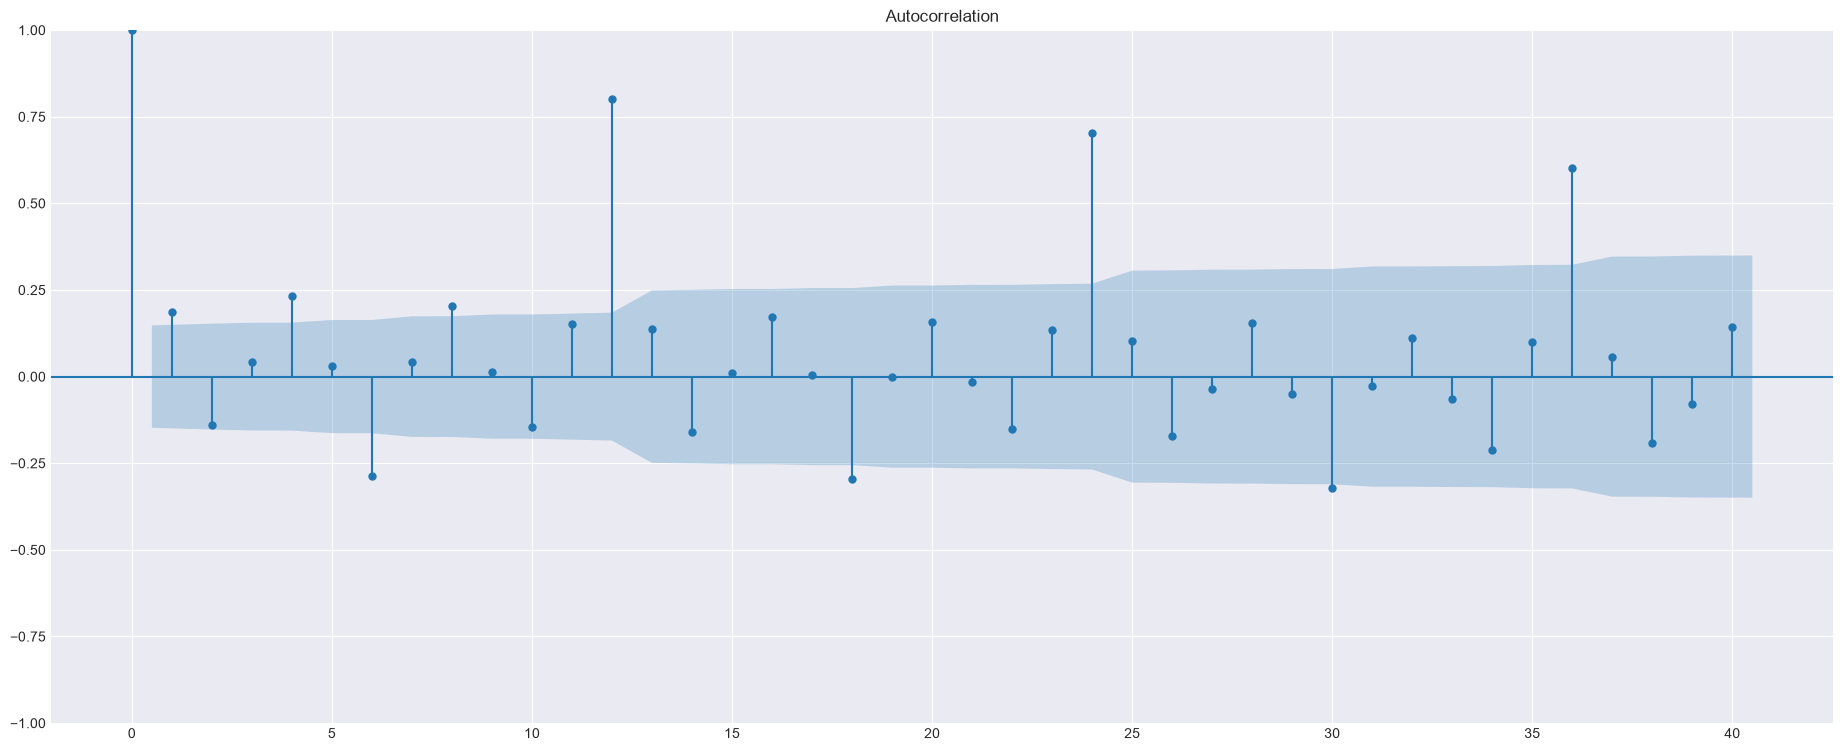

In [39]:
_ = plot_acf(df["sales"], lags=40)

У дневного panel-ряда первые лаги значимы (тренд) + всплески на лагах 7 и 365 (недельная и годовая сезонность).

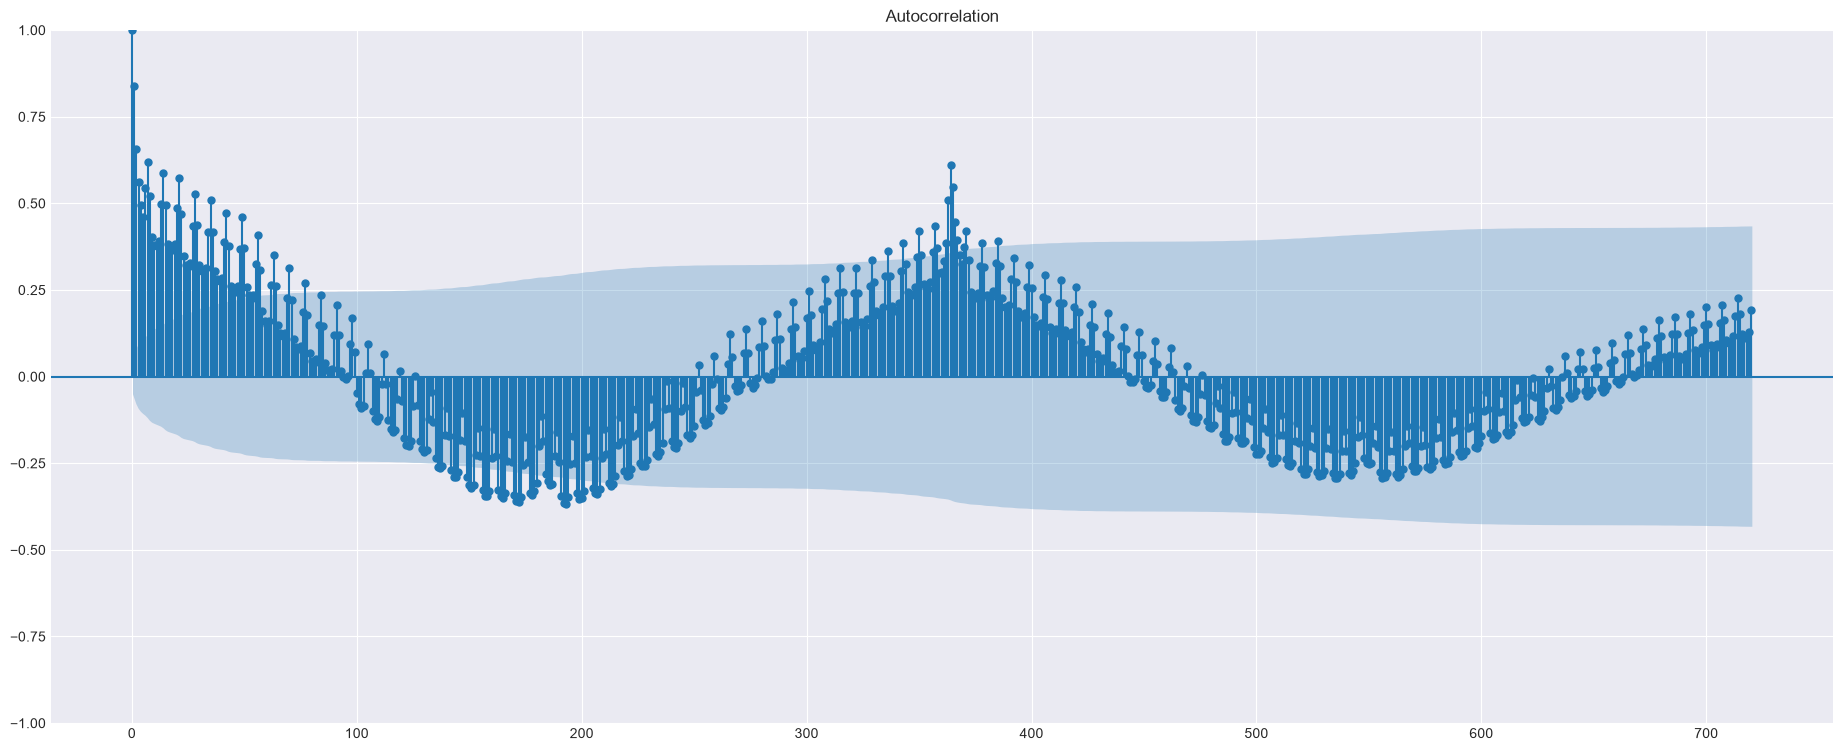

In [40]:
_ = plot_acf(df_panel[segments[0]], lags=720)

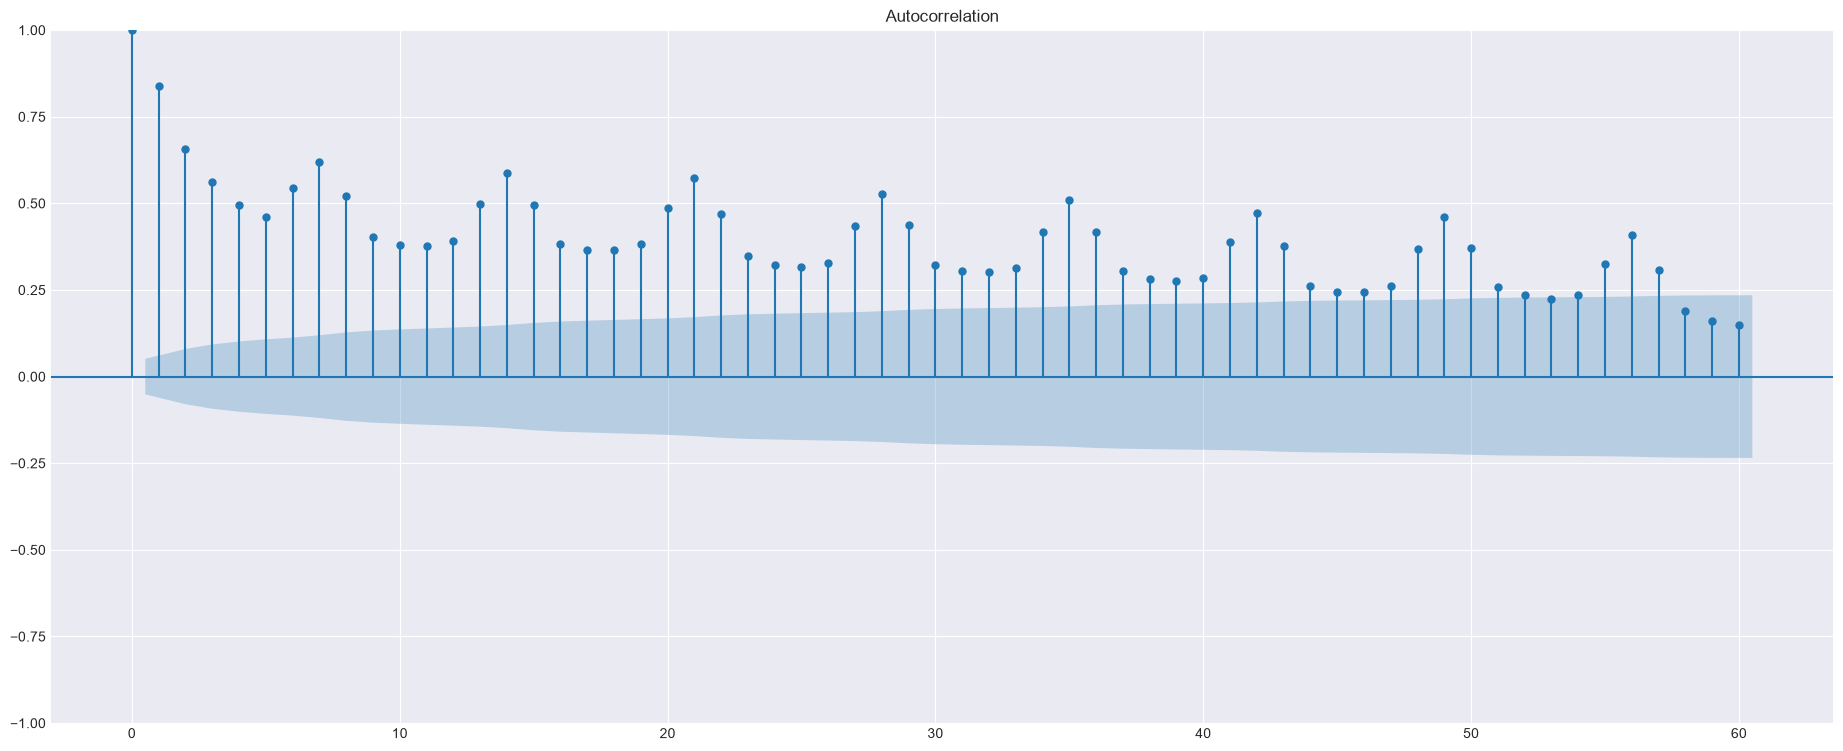

In [41]:
_ = plot_acf(df_panel[segments[0]], lags=60)

## 5. Кросс-корреляция

До сих пор ряд сравнивался сам с собой. Теперь посмотрим на **линейную связь между разными рядами** — например, между продажами и погодой.

### Матрица корреляций

In [42]:
df_panel_slice = df_panel.loc[:, "Finland_KaggleMart_Kaggle Hat"]
df_exog_slice = df_exog["Finland_KaggleMart_Kaggle Hat"]
df_panel_with_exog = pd.concat([df_exog_slice, df_panel_slice], axis=1).dropna()
df_panel_with_exog.head()

,precipitation,snow_depth,tavg,tmax,tmin,Finland_KaggleMart_Kaggle Hat
timestamp,,,,,,
2015-01-01,1.714141,284.545455,1.428571,2.912739,-1.015287,520.0
2015-01-02,10.016667,195.000000,0.553571,2.358599,-0.998718,493.0
2015-01-03,3.956061,284.294118,-1.739286,0.820382,-3.463871,535.0
2015-01-04,0.246193,260.772727,-7.035714,-3.110828,-9.502581,544.0
2015-01-05,0.036364,236.900000,-17.164286,-8.727564,-19.004487,378.0


Сильнее всего «продажи» коррелируют с «глубиной снега».

In [43]:
correlation_matrix = df_panel_with_exog.corr()
correlation_matrix

,precipitation,snow_depth,tavg,tmax,tmin,Finland_KaggleMart_Kaggle Hat
precipitation,1.000000,-0.145403,0.204125,0.155323,0.248882,-0.125582
snow_depth,-0.145403,1.000000,-0.629383,-0.613713,-0.648156,0.498196
tavg,0.204125,-0.629383,1.000000,0.987786,0.977768,-0.254267
tmax,0.155323,-0.613713,0.987786,1.000000,0.945490,-0.221172
tmin,0.248882,-0.648156,0.977768,0.945490,1.000000,-0.300801
Finland_KaggleMart_Kaggle Hat,-0.125582,0.498196,-0.254267,-0.221172,-0.300801,1.000000


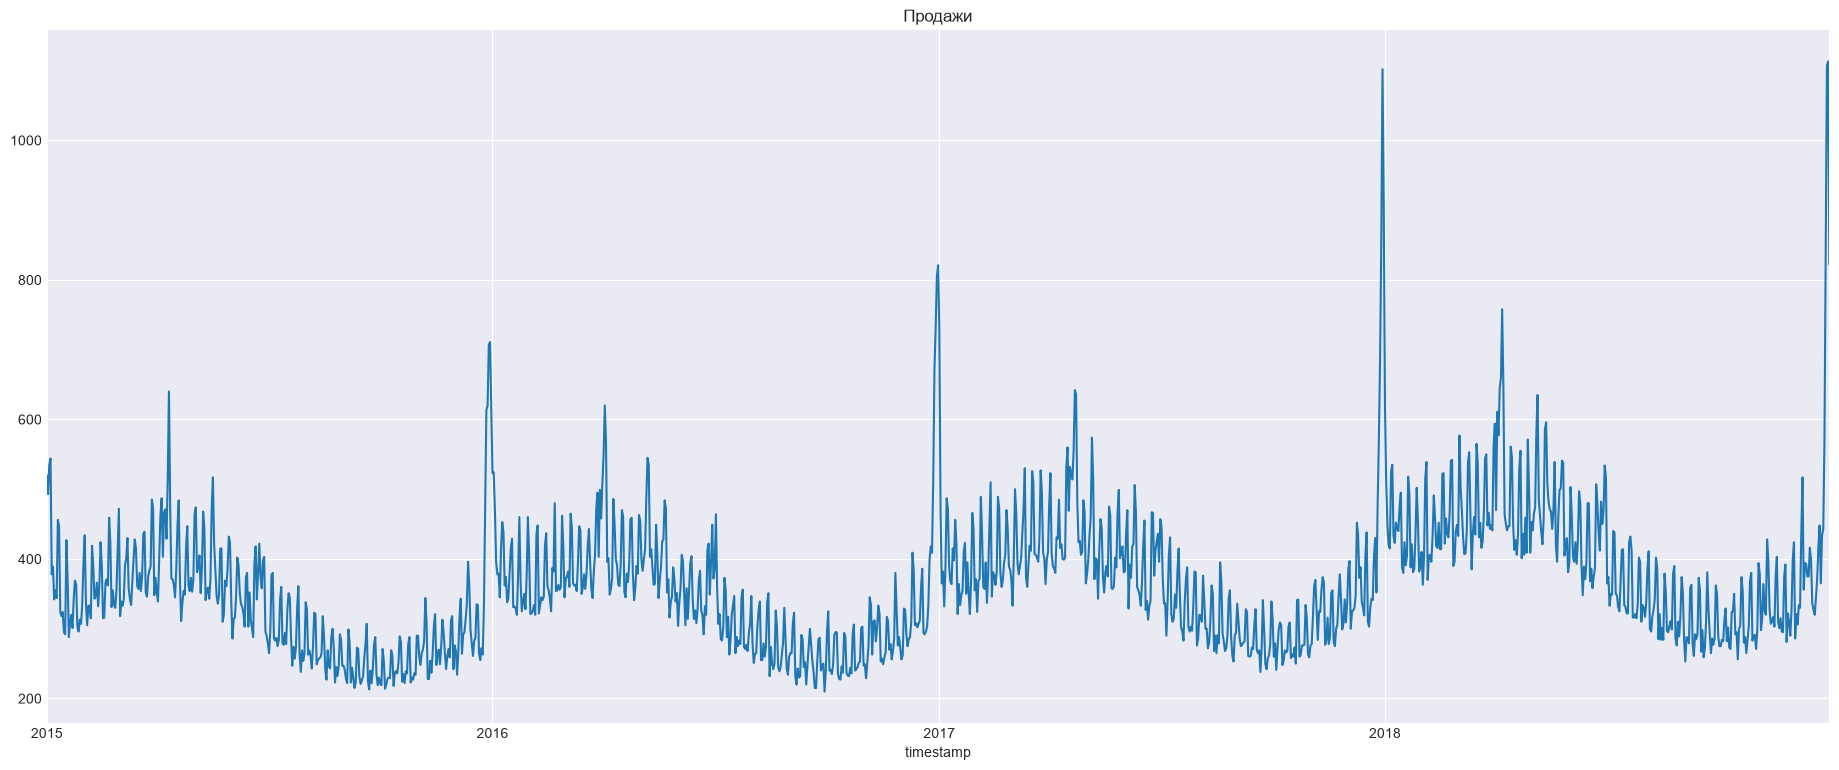

In [44]:
df_panel_with_exog["Finland_KaggleMart_Kaggle Hat"].plot(title="Продажи");

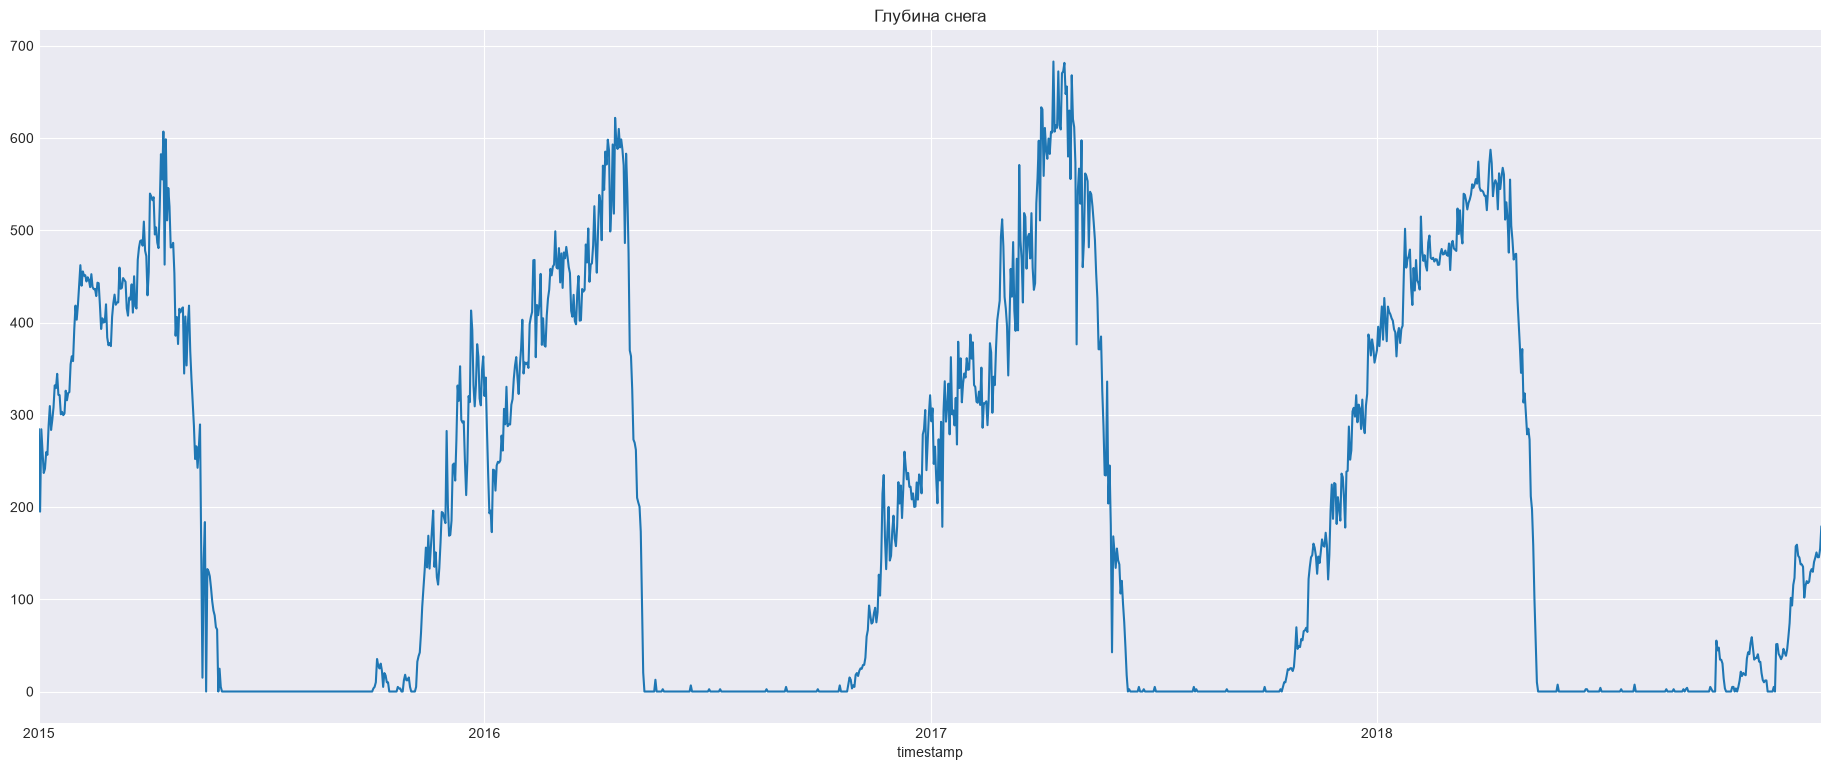

In [45]:
df_panel_with_exog["snow_depth"].plot(title="Глубина снега");

### Кросс-корреляция со сдвигом

Матрица корреляций смотрит на связь «в один и тот же момент». Но связь может проявляться **с задержкой**. Функция кросс-корреляции ищет лаг, на котором связь максимальна.

Ниже видно: температура сильнее всего скоррелирована с глубиной снега с лагом ~180 дней — чем больше снега полгода назад, тем теплее сейчас (логично!).

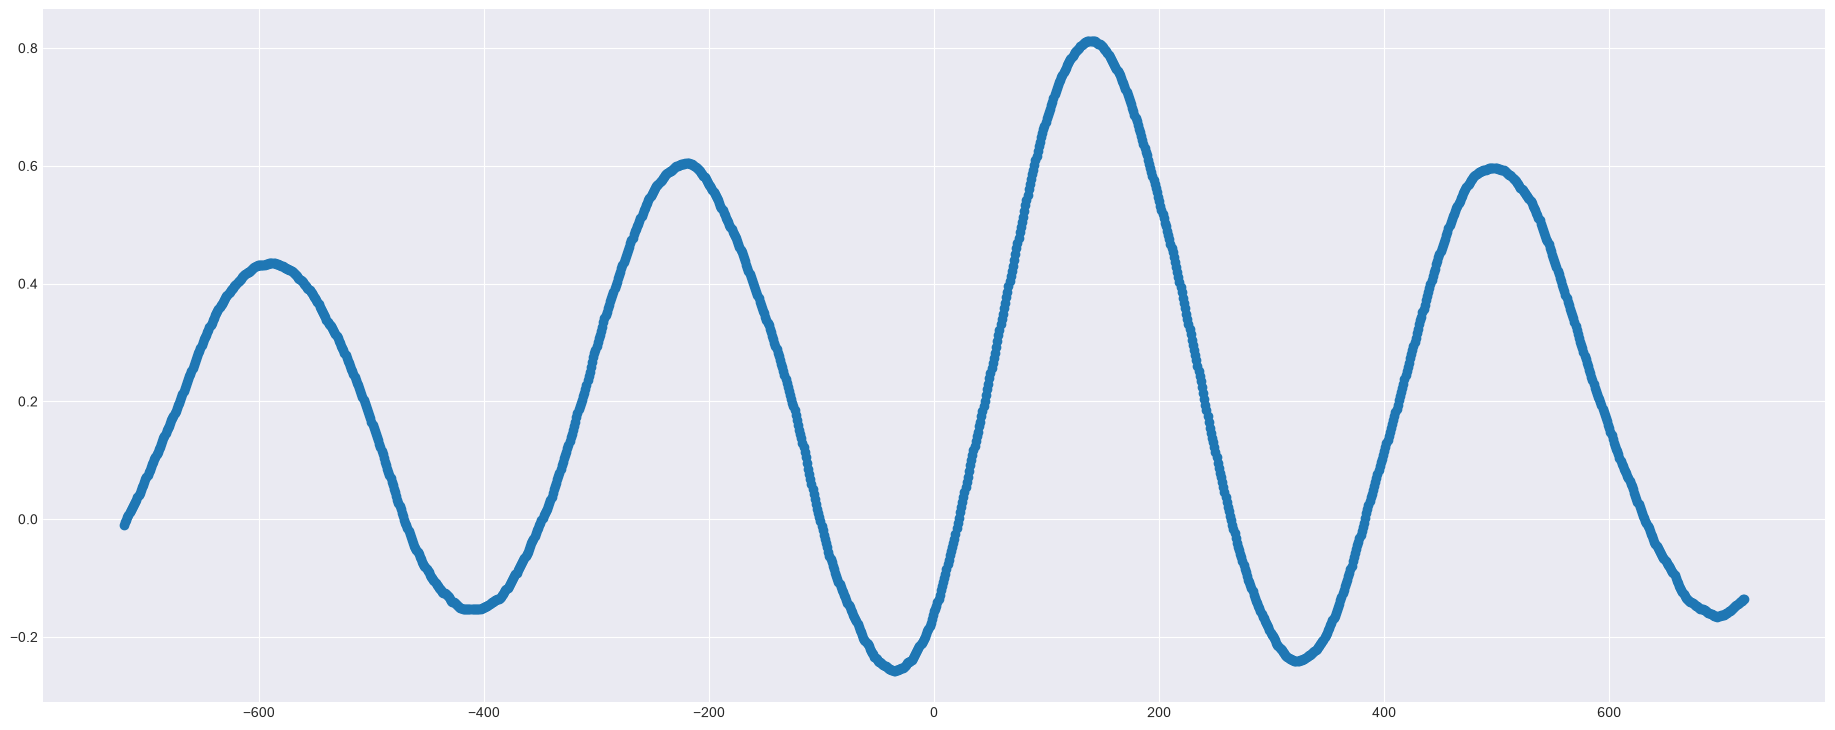

In [46]:
_ = plt.xcorr(
    df_panel_with_exog["tavg"],
    df_panel_with_exog["snow_depth"],
    usevlines=False,
    maxlags=720,
    normed=True,
    lw=2,
)

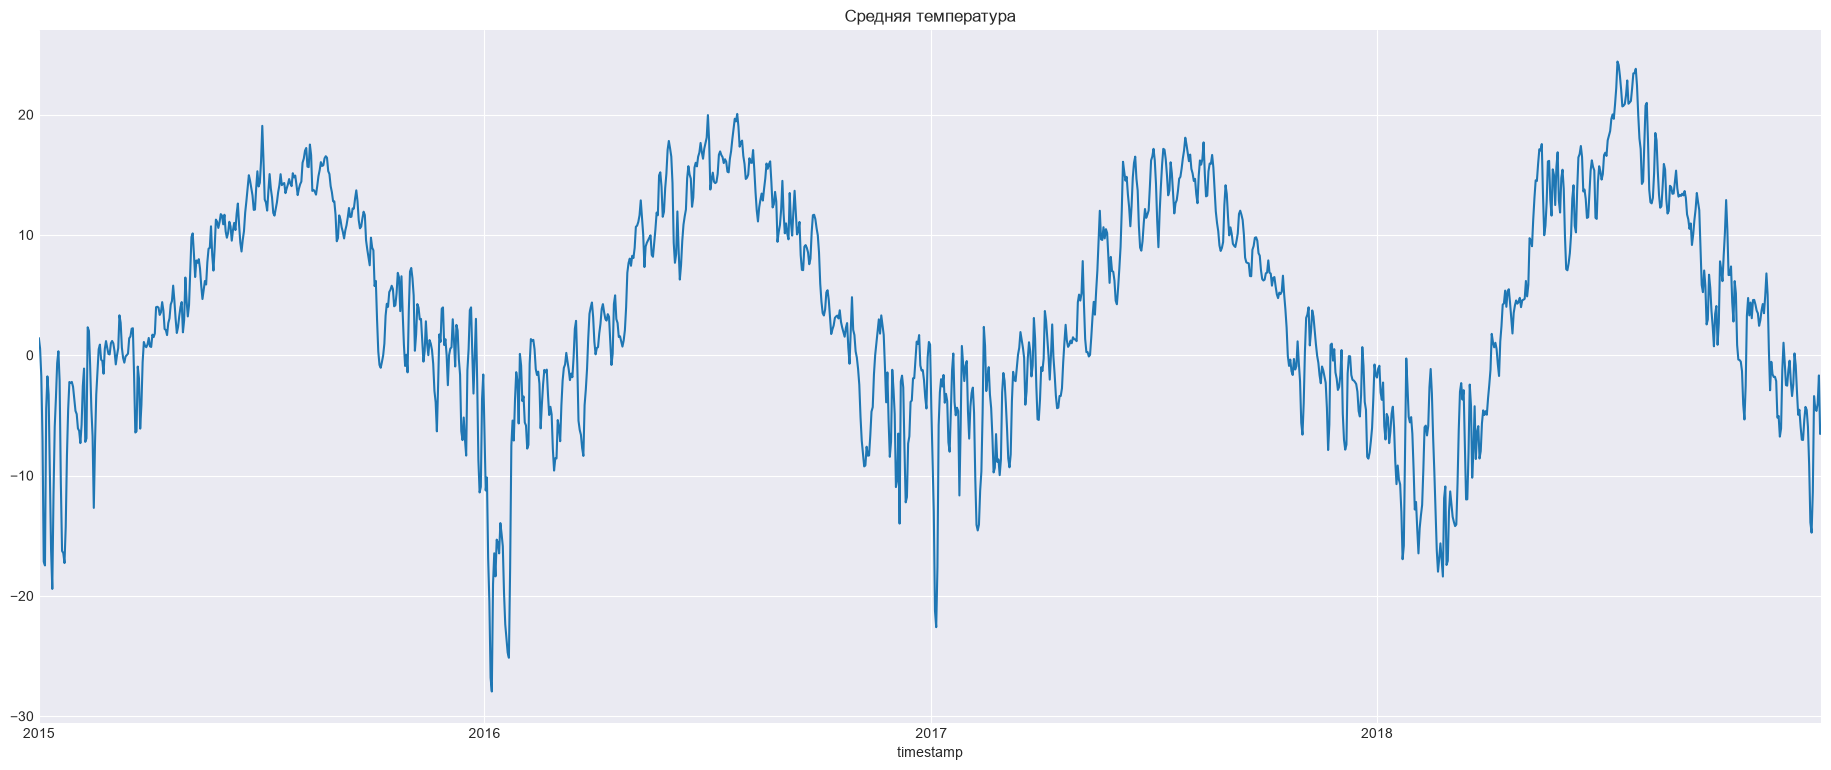

In [47]:
df_panel_with_exog["tavg"].plot(title="Средняя температура");

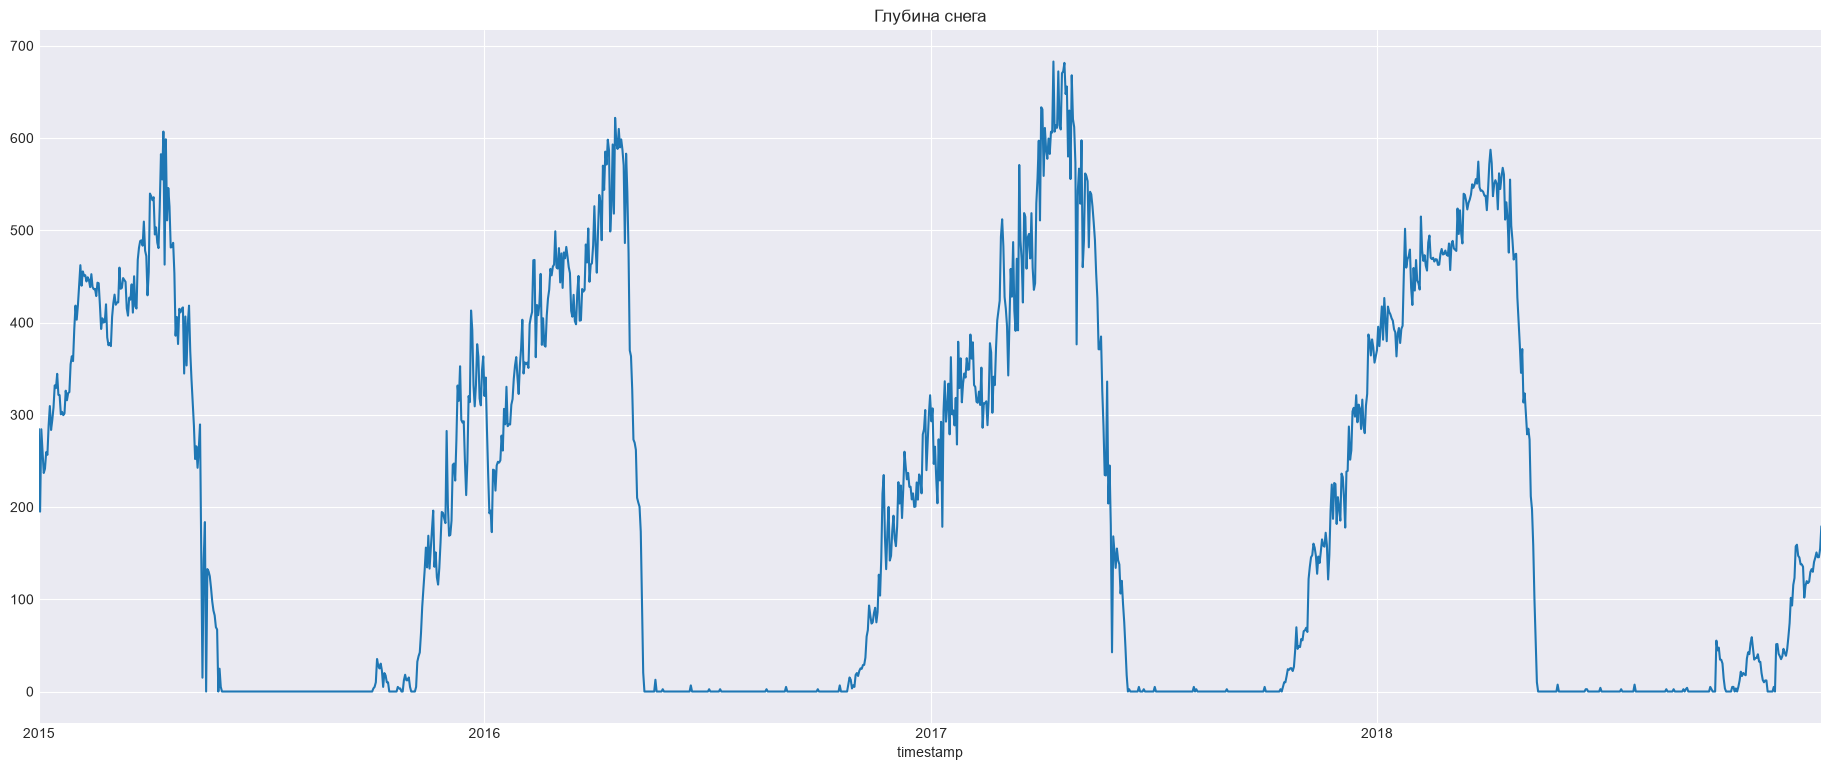

In [48]:
df_panel_with_exog["snow_depth"].plot(title="Глубина снега");

Наложим оба ряда (после стандартизации) — один повторяет другой с запаздыванием примерно в полгода.

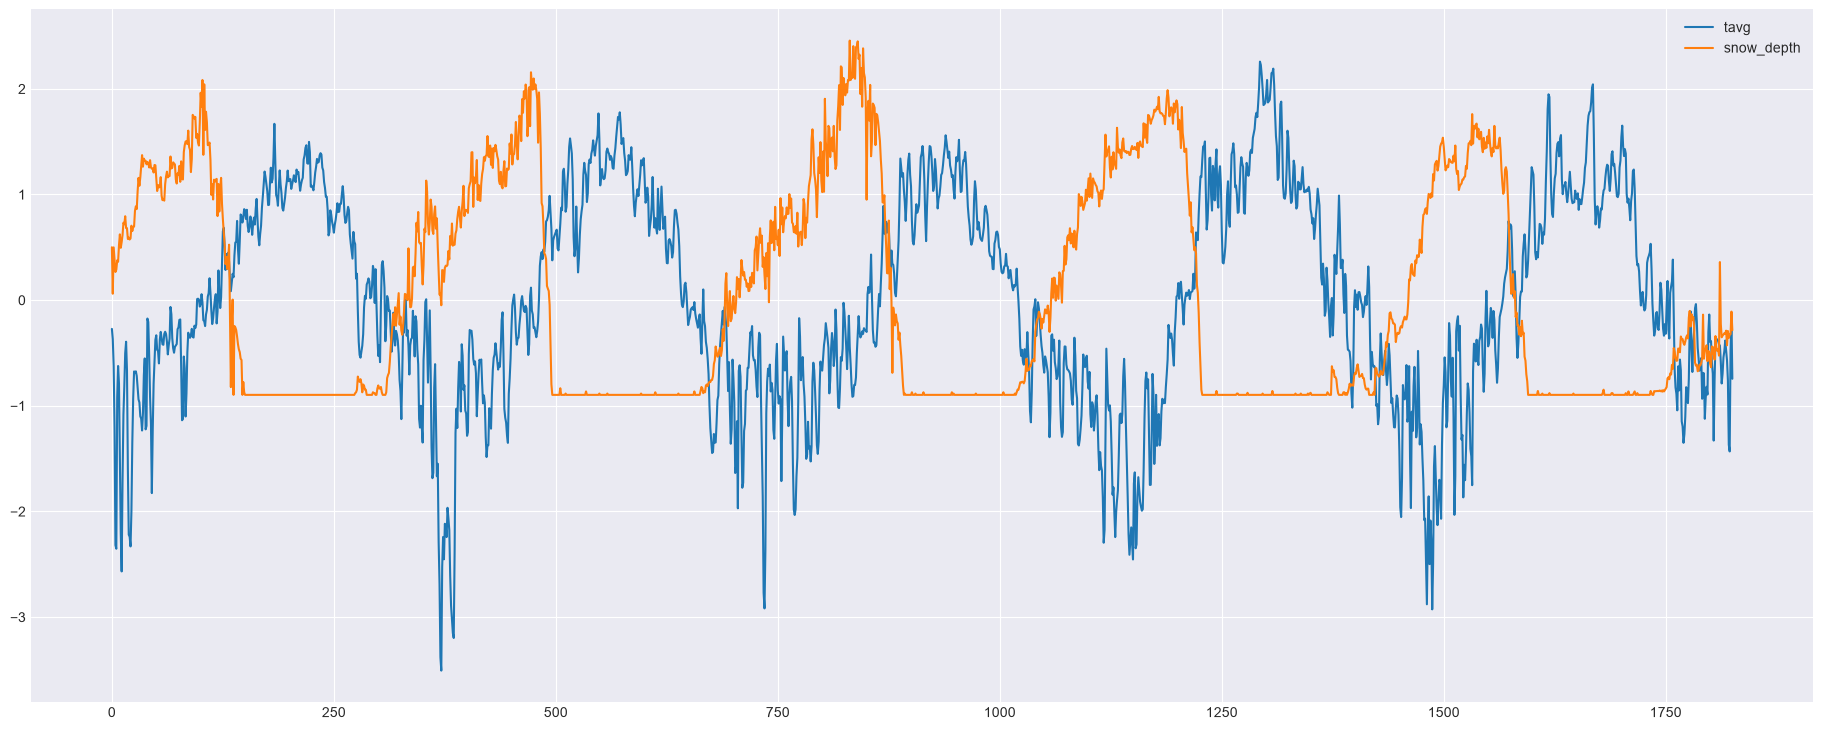

In [49]:
from sklearn.preprocessing import StandardScaler

plt.plot(StandardScaler().fit_transform(df_exog_slice[["tavg", "snow_depth"]]))
plt.legend(["tavg", "snow_depth"]);

## 6. Календарные эффекты (праздники)

Отдельные всплески в ряду часто объясняются **событиями**. Посмотрим внимательно на panel-ряд.

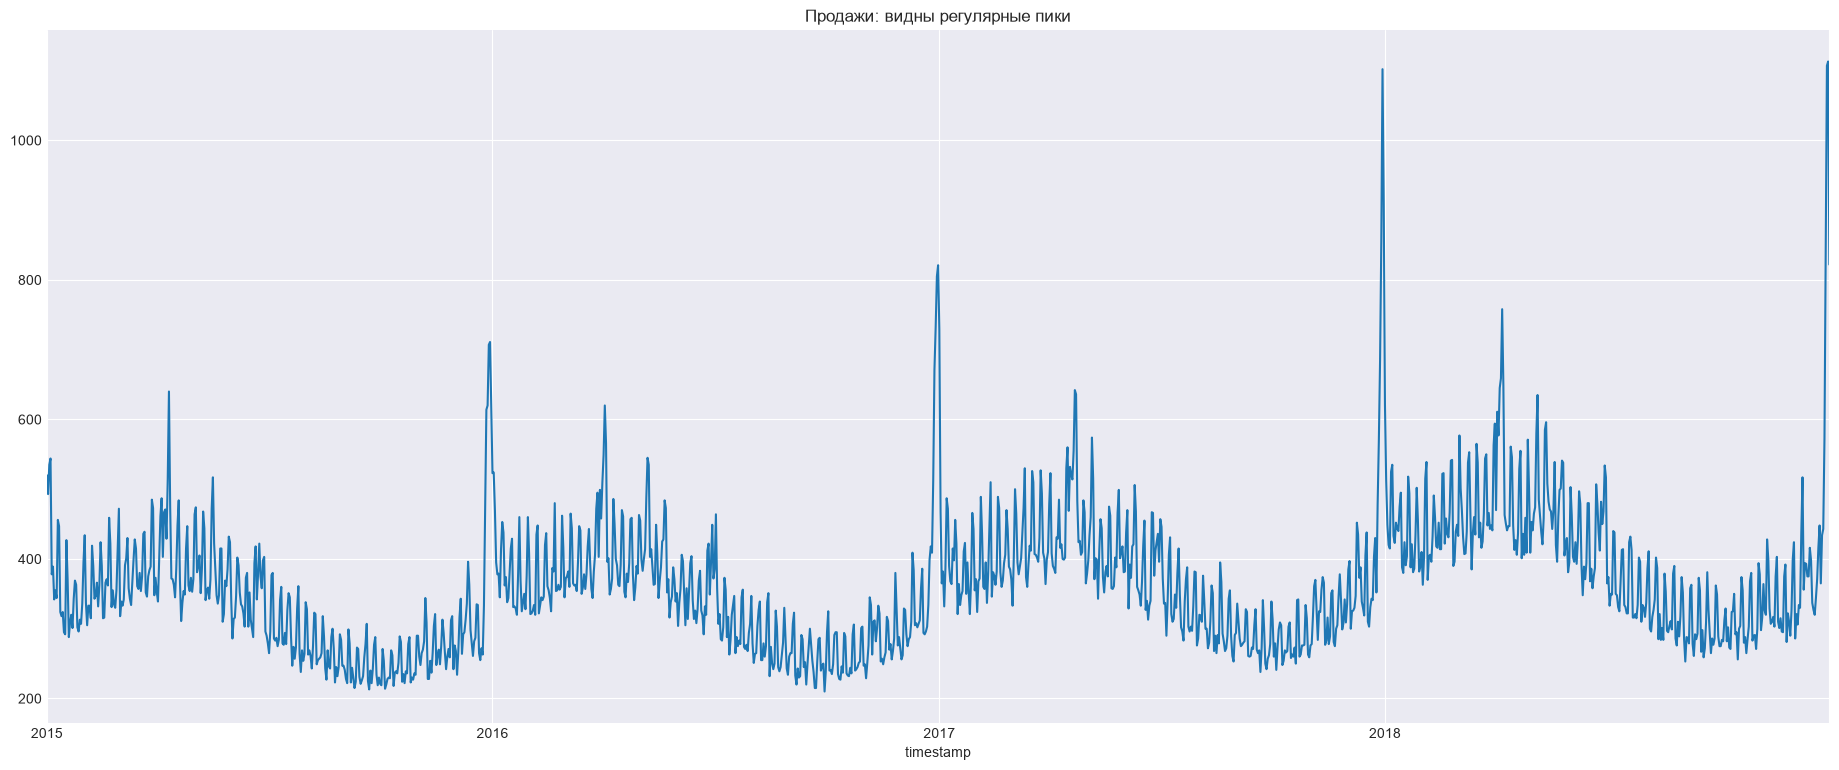

In [50]:
df_panel_slice.plot(title="Продажи: видны регулярные пики");

Если приглядеться — каждый год за день до 31 декабря люди закупаются подарками: пики обусловлены событием.

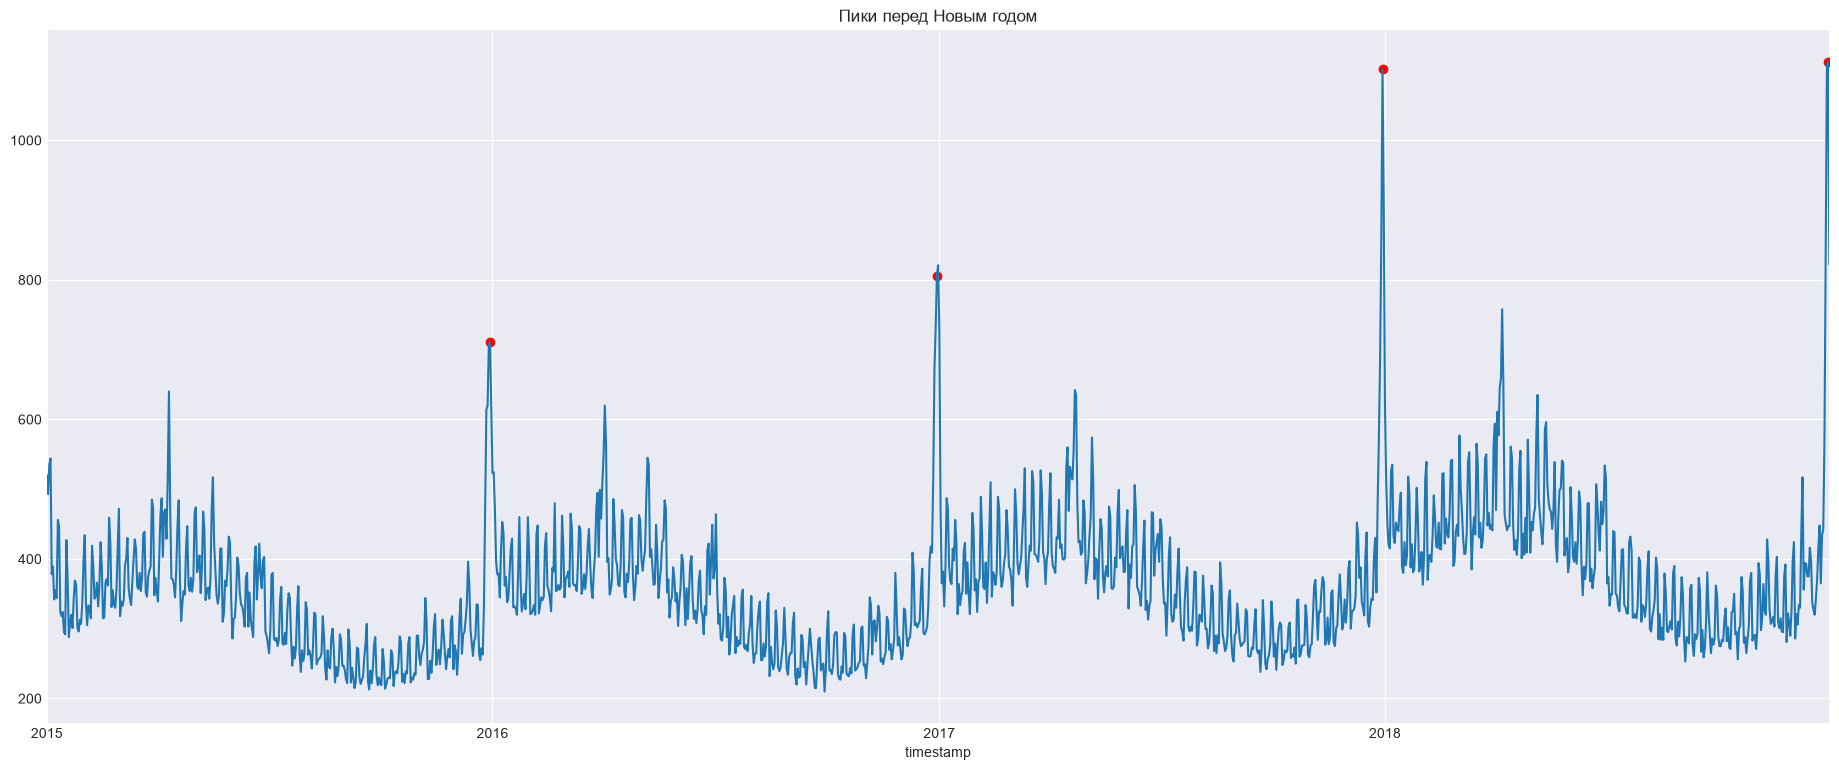

In [51]:
day_before_new_year = ["2015-12-30", "2016-12-30", "2017-12-30", "2018-12-30"]
df_panel_slice.plot()
plt.scatter(day_before_new_year, df_panel_slice[day_before_new_year].values, c="r")
plt.title("Пики перед Новым годом");

Все праздничные даты можно получить из библиотеки [`holidays`](https://github.com/vacanza/holidays).

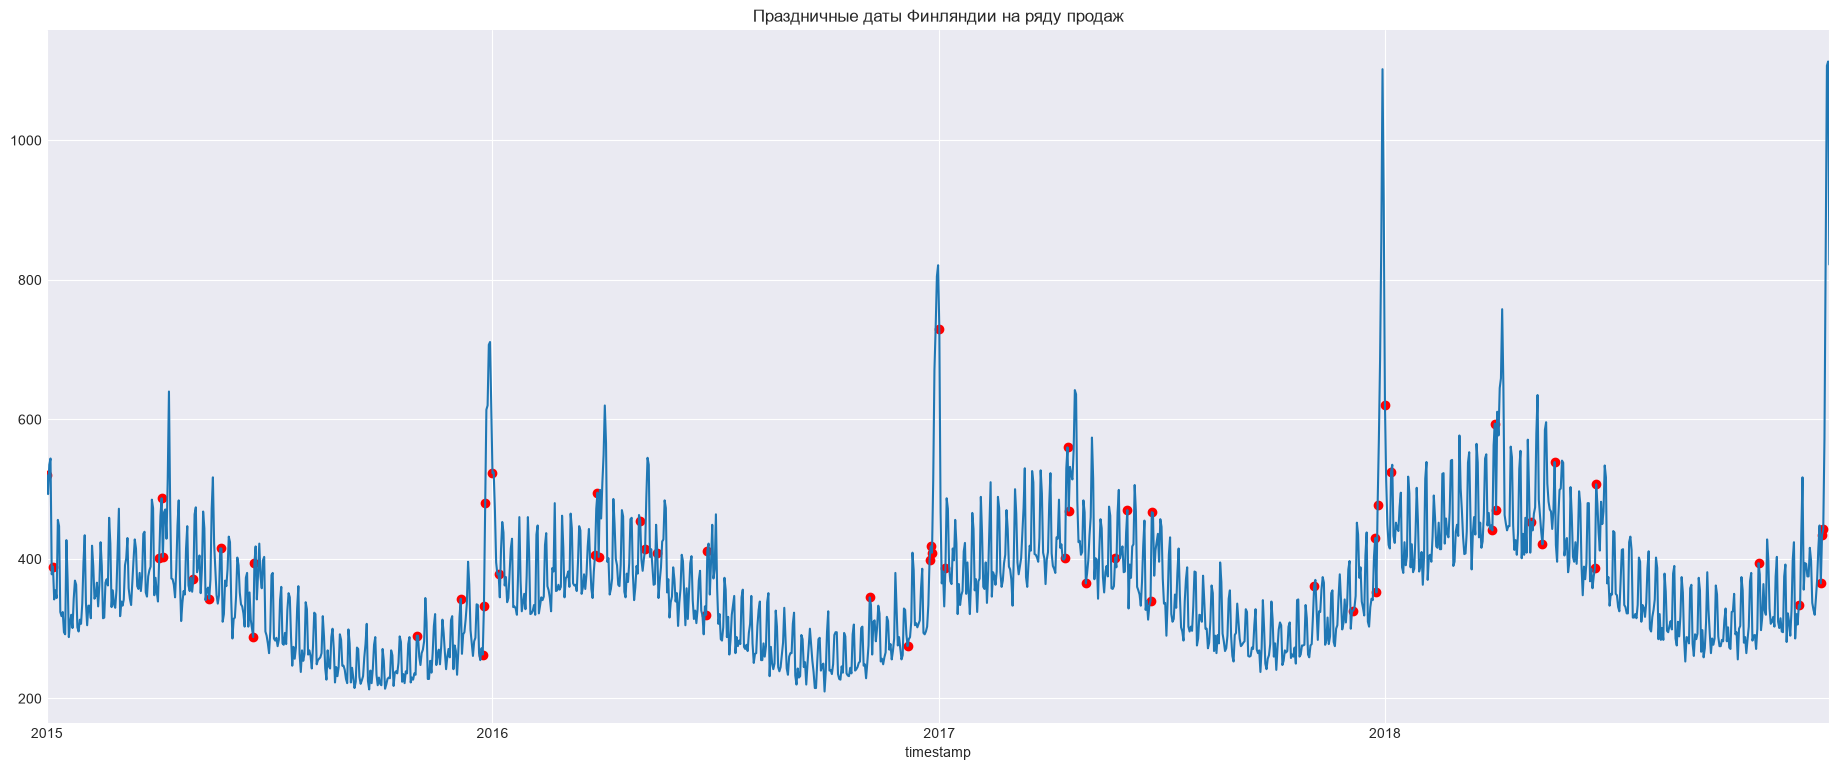

In [52]:
import holidays

fin_holidays = holidays.FIN()
holiday_dates = [date for date in df_panel_slice.index if date in fin_holidays]

df_panel_slice.plot()
plt.scatter(holiday_dates, df_panel_slice[holiday_dates].values, c="r")
plt.title("Праздничные даты Финляндии на ряду продаж");

## Итог пункта

Мы разобрали ключевые **характеристики временного ряда**:

| Характеристика | Что показывает | Инструменты |
|---|---|---|
| Компоненты | тренд / сезонность / остаток | `seasonal_decompose`, `STL` |
| Сезонность | форму и стабильность профиля | seasonal plot, `month_plot`, `quarter_plot`, polar |
| Стационарность | постоянство статистик во времени | ADF, KPSS |
| Автокорреляция | связь с прошлыми лагами | `acf`, `plot_acf` |
| Кросс-корреляция | связь с другими рядами (в т.ч. со сдвигом) | `corr`, `plt.xcorr` |
| Календарные эффекты | влияние событий | `holidays` |

Эти характеристики — фундамент выбора модели прогнозирования, к которому мы перейдём на следующих семинарах.